# galerie — beau_graphique

Démo visuelle exécutable de tous les modules : `beau_graphique`, `narratif`, `pipeline`, `themes`.
Données réalistes (contexte Cameroun / FCFA) pour juger rapidement si la librairie correspond au besoin.

Exécuter cellule par cellule (Kernel → Restart & Run All pour tout regénérer).

## 0. Setup

In [1]:
from beau_graphique import (
    init, ligne, barres, barres_groupees, aire, histogramme,
    nuage, camembert, heatmap, dashboard,
    dot_plot_comparatif, bulle_4d, unit_chart,
    box_plot, violin, waterfall, lollipop, slope, facet,
    enregistrer_couleurs, reinitialiser_couleurs,
    colorier_si, colorier_selon,
    layout_rapport, THEMES,
)
from export import sauvegarder, pdf_rapport, export_batch
from narratif import (
    barres_focus, ligne_focus, comparaison_avant_apres, barres_ranked,
    divergent, bullet_chart, barres_connectees, palette_focus, ACCENTS,
    annoter_zone, annoter_seuil, annoter_delta, annoter_point,
)
from pipeline import inspecter, nettoyer, depuis_df, barres_df, ligne_df, nuage_df, histogramme_df
from themes import appliquer, lister, apercu, depuis_couleur, palette_safe, reinitialiser

import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt

init()
np.random.seed(42)


✓ Style beau_graphique activé (thème : light).


## 🚀 Démarrage rapide — de zéro à un graphique en 5 lignes

Copie-colle le bloc ci-dessous dans n'importe quel notebook pour obtenir immédiatement un graphique publiable.

✓ Style beau_graphique activé (thème : light).


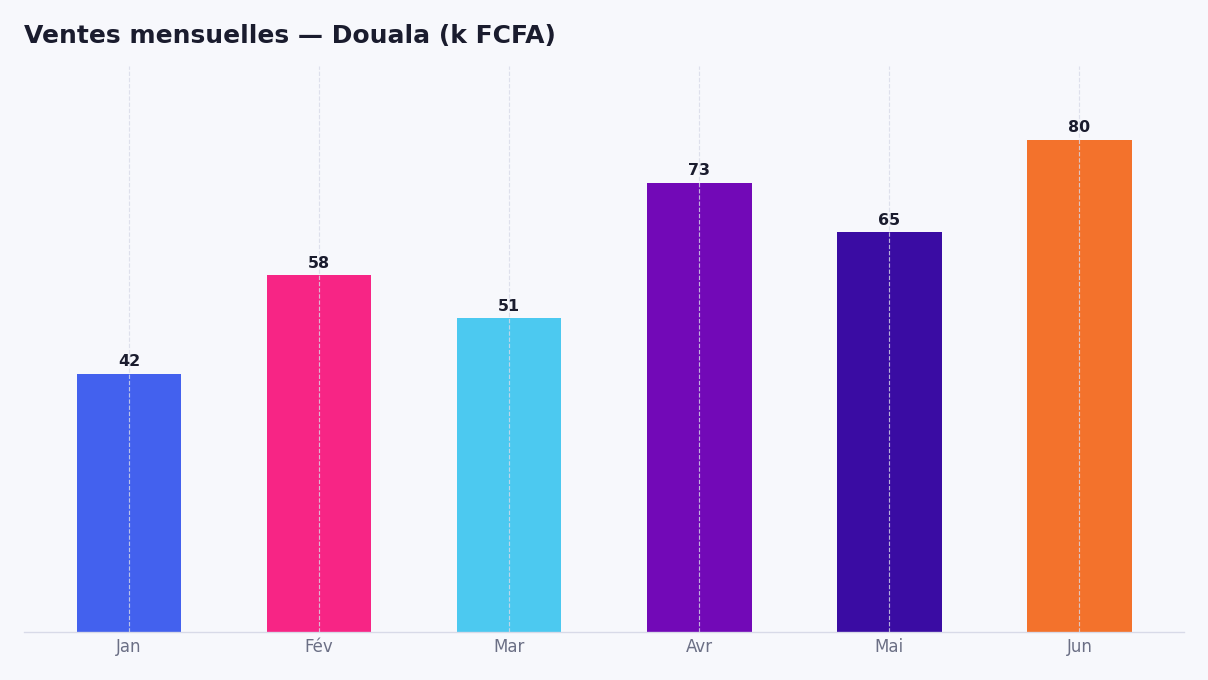

In [2]:
from beau_graphique import init, barres
import matplotlib.pyplot as plt

init()   # active le style une fois pour toute la session

barres(
    categories=["Jan", "Fév", "Mar", "Avr", "Mai", "Jun"],
    valeurs=[42, 58, 51, 73, 65, 80],
    titre="Ventes mensuelles — Douala (k FCFA)",
    couleurs_multiples=True,
)
plt.show()

### En 10 lignes — une slide complète prête à exporter

`layout_rapport()` + n'importe quelle fonction + `sauvegarder()` : c'est le workflow complet de la librairie.

✓ Style beau_graphique activé (thème : light).


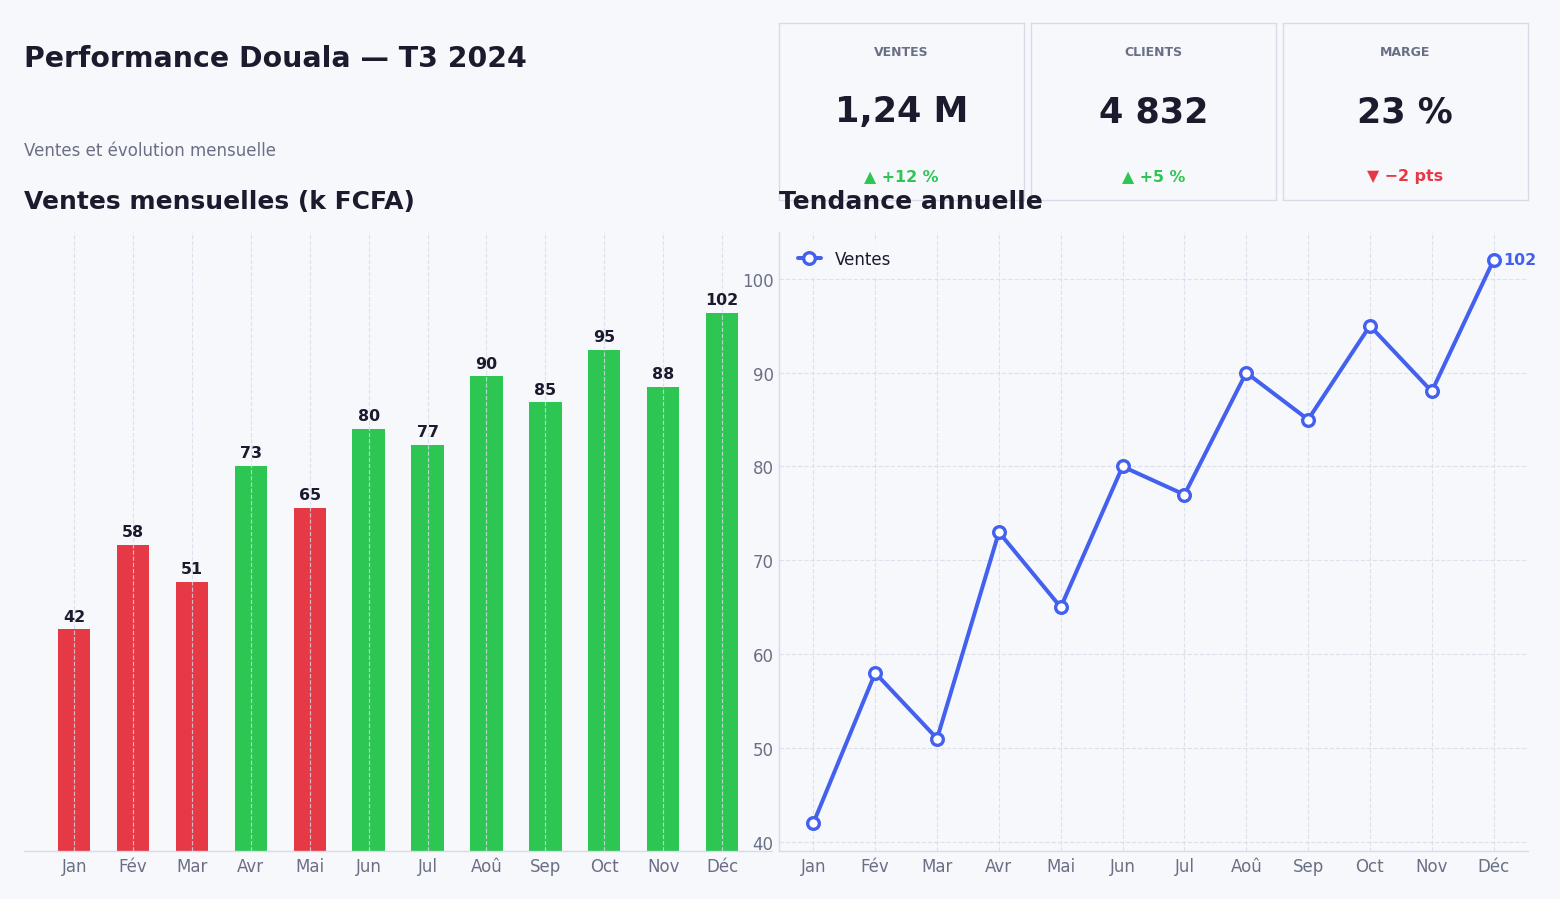

In [3]:
from beau_graphique import init, barres, ligne, layout_rapport, colorier_si
from export import sauvegarder
import matplotlib.pyplot as plt

init()

fig, zones = layout_rapport(
    titre="Performance Douala — T3 2024",
    sous_titre="Ventes et évolution mensuelle",
    kpis=[
        {"label": "Ventes",  "valeur": "1,24 M", "delta": "+12 %", "positif": True},
        {"label": "Clients", "valeur": "4 832",  "delta": "+5 %",  "positif": True},
        {"label": "Marge",   "valeur": "23 %",   "delta": "−2 pts","positif": False},
    ],
    n_graphiques=2,
    format="slide",
)

mois_ex = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
ventes_ex = [42,58,51,73,65,80,77,90,85,95,88,102]

barres(mois_ex, ventes_ex,
       titre="Ventes mensuelles (k FCFA)",
       fn_couleur=colorier_si(70),          # vert si > 70, rouge sinon
       ax=zones["graphiques"][0])

ligne(mois_ex,
      y_series={"Ventes": ventes_ex},
      titre="Tendance annuelle",
      ax=zones["graphiques"][1])

plt.show()
# sauvegarder(fig, "slide_t3", dossier="exports/", fmt=["png","pdf"])

## 🗺️ Guide de choix — quelle fonction pour quel message ?

| Mon message / Ma question | Fonction recommandée |
|---|---|
| **Évolution temporelle** | |
| Tendance sur une ou plusieurs séries | `ligne()` |
| Tendance avec focus sur une série clé | `ligne_focus()` |
| **Comparer des catégories** | |
| Classer (< 15 catégories) | `barres()` |
| Classer beaucoup de catégories (15-40) | `lollipop()` |
| Mettre en évidence le top-N | `barres_ranked()` |
| Mettre en avant une catégorie spécifique | `barres_focus()` |
| Variations pos. / nég. autour de zéro | `divergent()` |
| **Composition** | |
| Parts d'un tout (< 6 segments) | `camembert()` |
| Décomposer une variation (pont) | `waterfall()` |
| **Distribution statistique** | |
| Dispersion + outliers | `box_plot()` |
| Distribution complète + densité | `violin()` |
| **Comparaison avant / après** | |
| 2 périodes, plusieurs indicateurs | `dot_plot_comparatif()` |
| Avant / Après sur 2 valeurs | `comparaison_avant_apres()` |
| Évolution par catégorie (2 dates) | `slope()` |
| Évolution séquentielle multi-périodes | `barres_connectees()` |
| **KPI & objectif** | |
| KPI vs cible vs plage de performance | `bullet_chart()` |
| **Multivariée** | |
| Corrélation entre 2 variables | `nuage()` |
| 4 dimensions en même temps | `bulle_4d()` |
| Proportions / ratios visuels | `unit_chart()` |
| **Petits multiples** | |
| Même graphique répété par segment | `facet()` |
| **Composition de page** | |
| Slide complète : KPIs + graphiques | `layout_rapport()` |
| Grille libre de graphiques | `dashboard()` |

> **Règle d'or :** une figure = un message. Si tu hésites entre deux fonctions, choisis la plus simple.

## 1. Données d'exemple

Un jeu de données mensuel (ventes FCFA, marges, régions) qui sert de fil rouge à toute la galerie.

In [4]:
mois = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]
dates_mensuelles = pd.date_range("2024-01-01", periods=12, freq="MS")

ventes_douala = [42, 48, 51, 55, 58, 62, 60, 65, 71, 68, 74, 79]
ventes_yaounde = [30, 35, 38, 42, 41, 45, 48, 50, 53, 55, 58, 61]

df = pd.DataFrame({
    "Mois": mois,
    "Date": dates_mensuelles,
    "Ventes_Douala": ventes_douala,
    "Ventes_Yaounde": ventes_yaounde,
    "Region": np.random.choice(["Littoral", "Centre", "Ouest"], size=12),
    "Marge_pct": np.random.normal(22, 4, 12).round(1),
})
df.head()


,Mois,Date,Ventes_Douala,Ventes_Yaounde,Region,Marge_pct
0,Jan,2024-01-01,42,30,Ouest,23.1
1,Fév,2024-02-01,48,35,Littoral,26.0
2,Mar,2024-03-01,51,38,Ouest,19.7
3,Avr,2024-04-01,55,42,Ouest,19.9
4,Mai,2024-05-01,58,41,Littoral,19.7


## 2. `beau_graphique.py` — graphiques de base

### `ligne()`

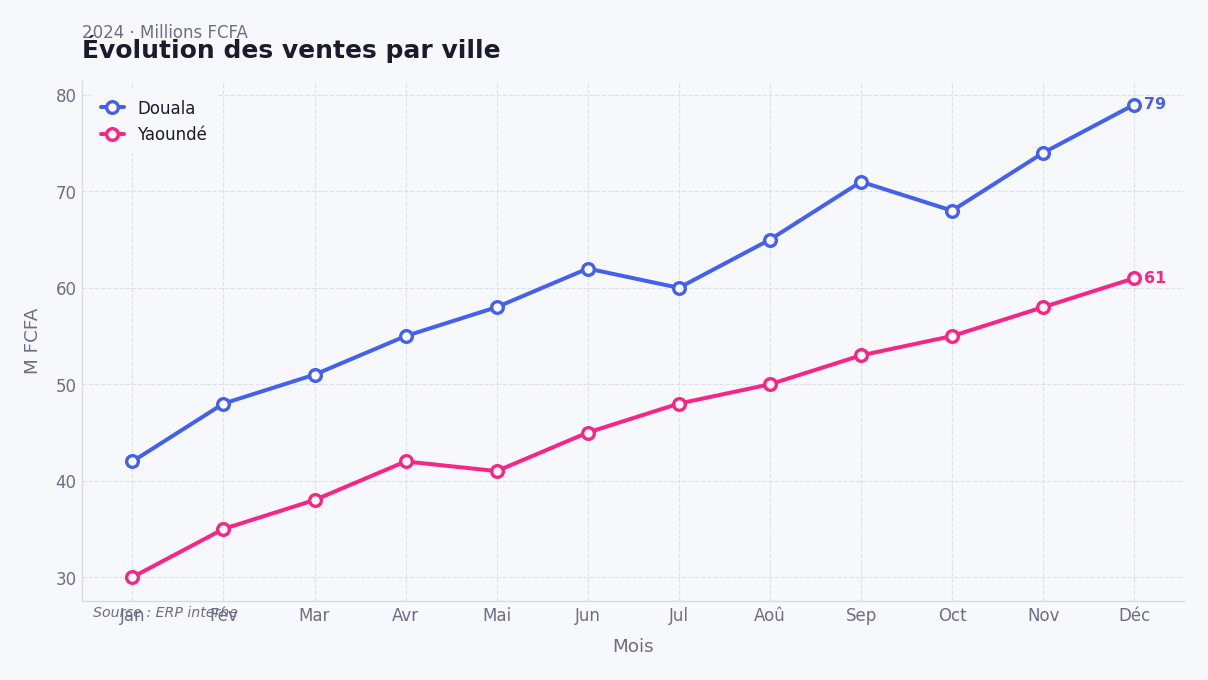

In [5]:
ligne(
    x=mois,
    y_series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    titre="Évolution des ventes par ville",
    sous_titre="2024 · Millions FCFA",
    xlabel="Mois", ylabel="M FCFA",
    note="Source : ERP interne",
)
plt.show()


### `barres()`

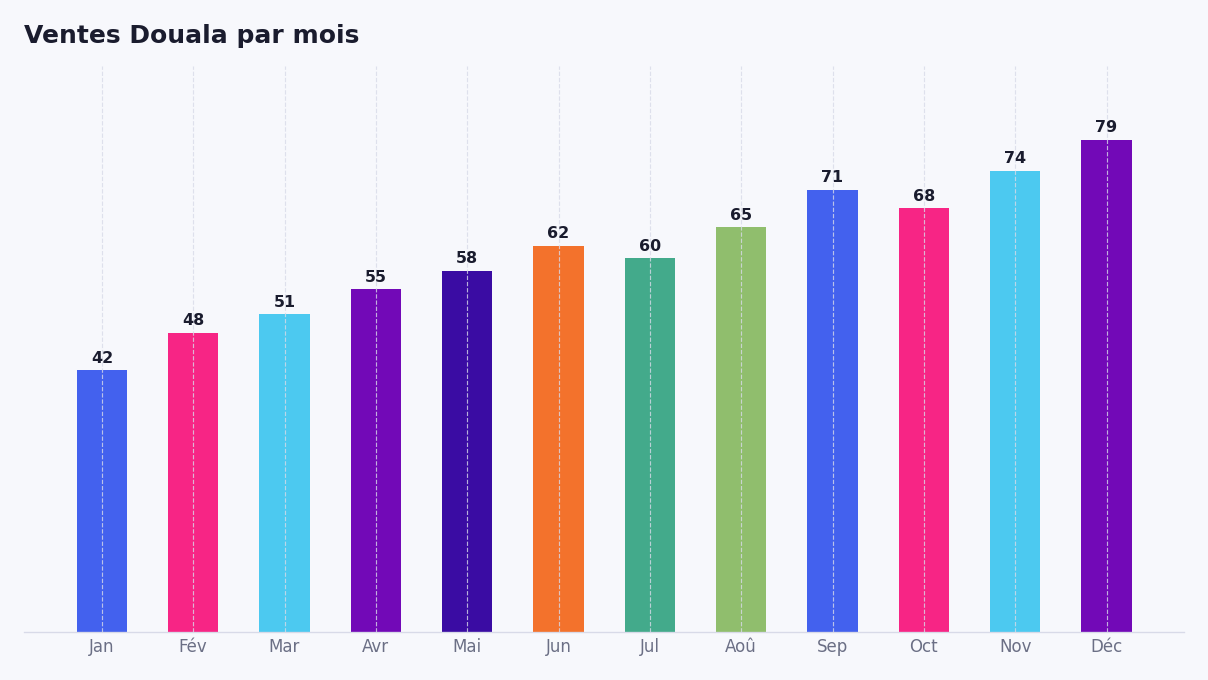

In [6]:
barres(
    categories=mois,
    valeurs=ventes_douala,
    titre="Ventes Douala par mois",
    ylabel="M FCFA",
    couleurs_multiples=True,
)
plt.show()


### `barres_groupees()`

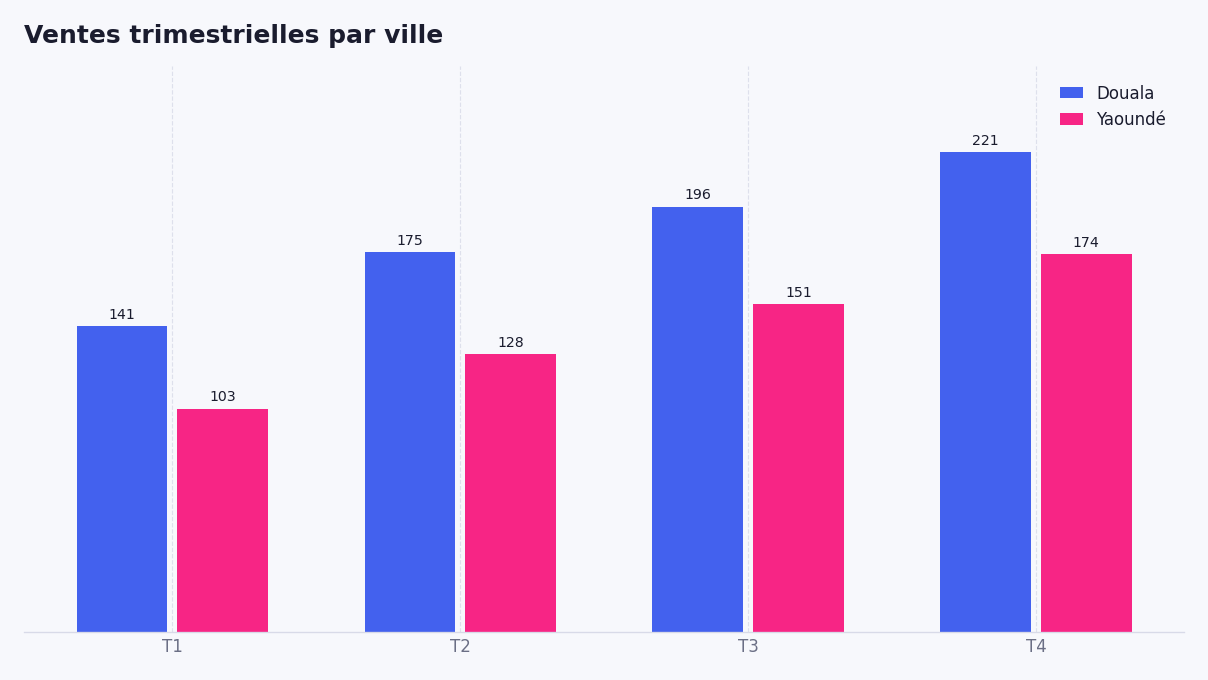

In [7]:
barres_groupees(
    categories=["T1", "T2", "T3", "T4"],
    groupes={
        "Douala": [141, 175, 196, 221],
        "Yaoundé": [103, 128, 151, 174],
    },
    titre="Ventes trimestrielles par ville",
    ylabel="M FCFA",
)
plt.show()


### `aire()`

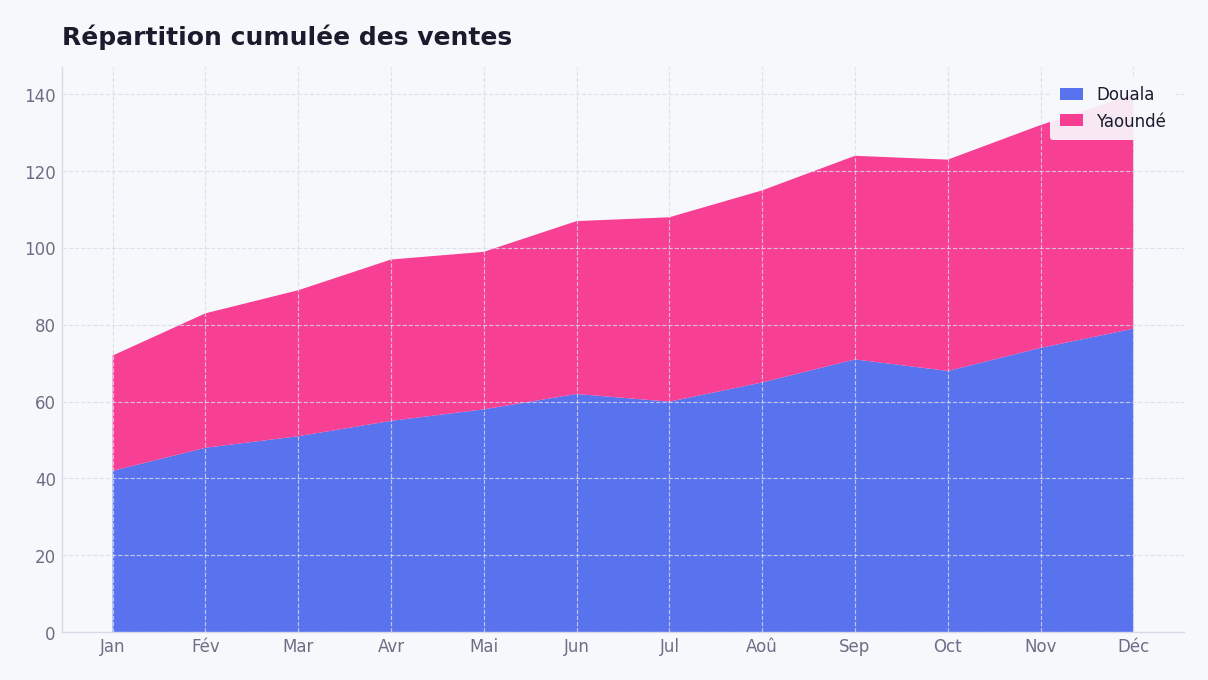

In [8]:
aire(
    x=mois,
    y_series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    titre="Répartition cumulée des ventes",
    empile=True,
)
plt.show()


### `histogramme()`

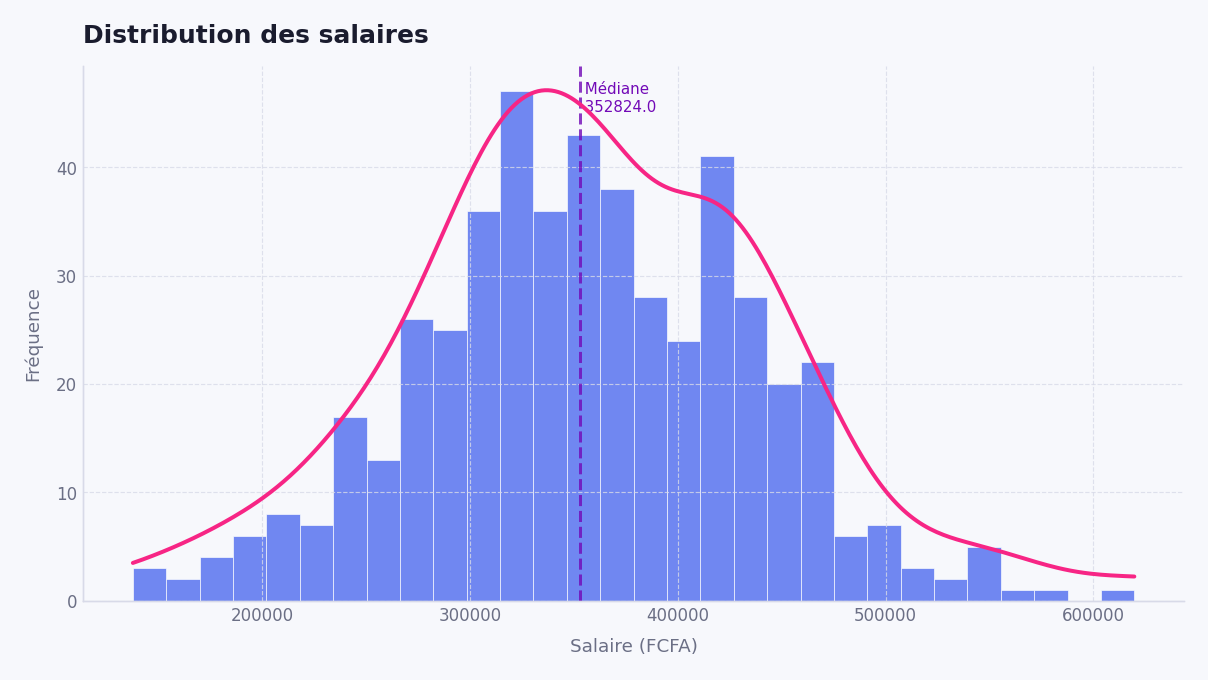

In [9]:
salaires = np.random.normal(350_000, 80_000, 500).clip(min=100_000)
histogramme(
    salaires,
    bins=30,
    titre="Distribution des salaires",
    xlabel="Salaire (FCFA)",
    courbe_densite=True,
)
plt.show()


### `nuage()`

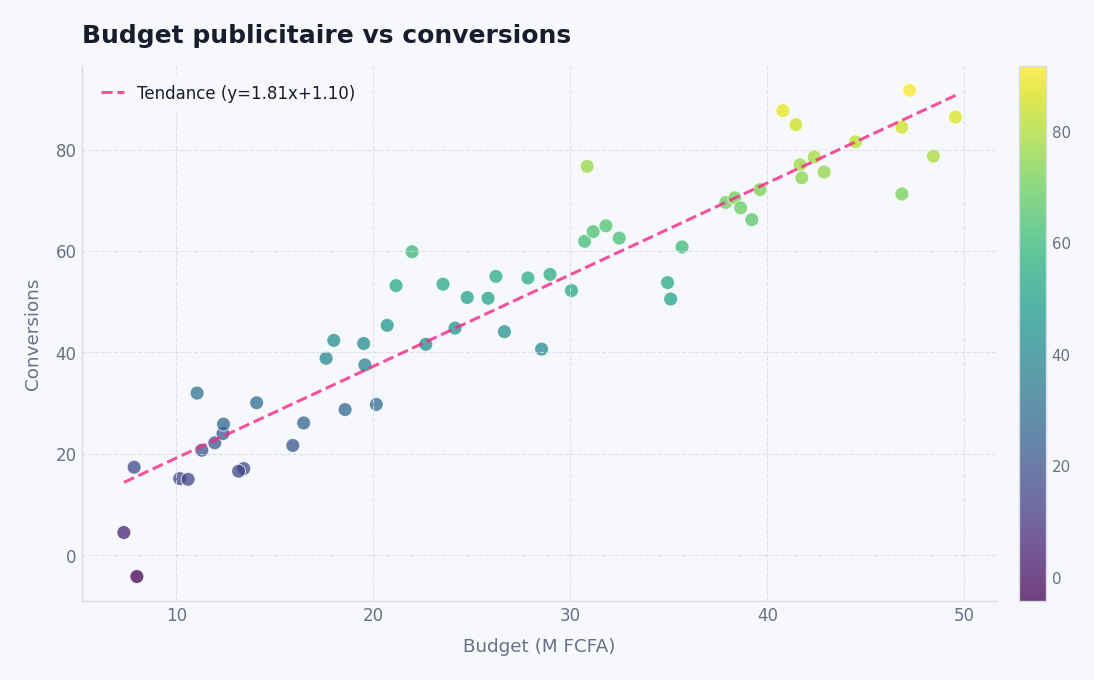

In [10]:
budget_pub = np.random.uniform(5, 50, 60)
conversions = budget_pub * 1.8 + np.random.normal(0, 8, 60)
nuage(
    budget_pub, conversions,
    couleur_var=conversions,
    titre="Budget publicitaire vs conversions",
    xlabel="Budget (M FCFA)", ylabel="Conversions",
    ligne_tendance=True,
)
plt.show()


### `camembert()`

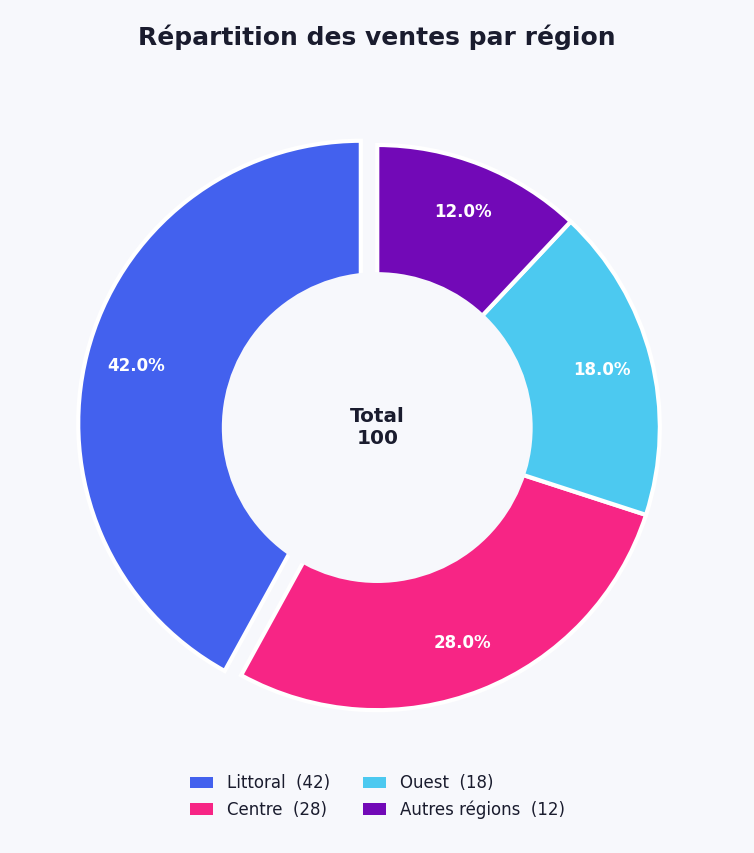

In [11]:
camembert(
    labels=["Littoral", "Centre", "Ouest", "Autres régions"],
    valeurs=[42, 28, 18, 12],
    titre="Répartition des ventes par région",
    donut=True,
)
plt.show()


### `heatmap()`

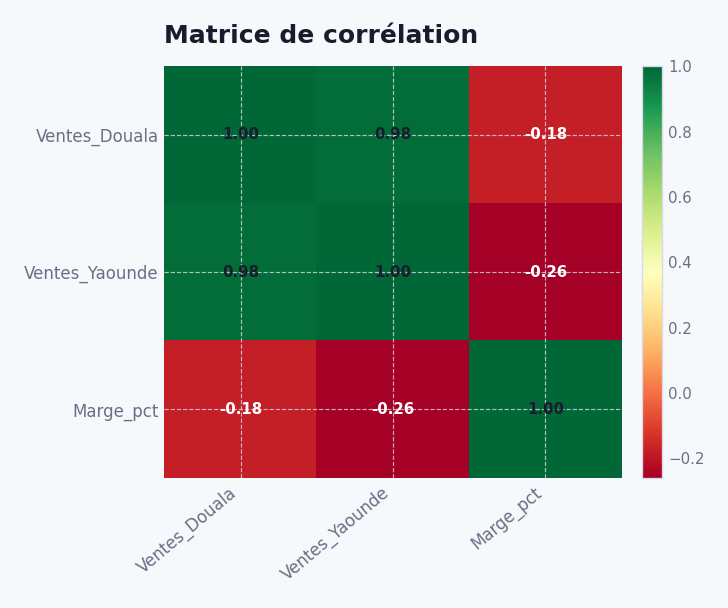

In [12]:
cols = ["Ventes_Douala", "Ventes_Yaounde", "Marge_pct"]
heatmap(
    df[cols].corr().values,
    labels_lignes=cols, labels_colonnes=cols,
    titre="Matrice de corrélation",
)
plt.show()


### `dashboard()`

Grille de graphiques dans une seule figure — construite directement via `GridSpec`,
sans copie d'artistes entre figures.

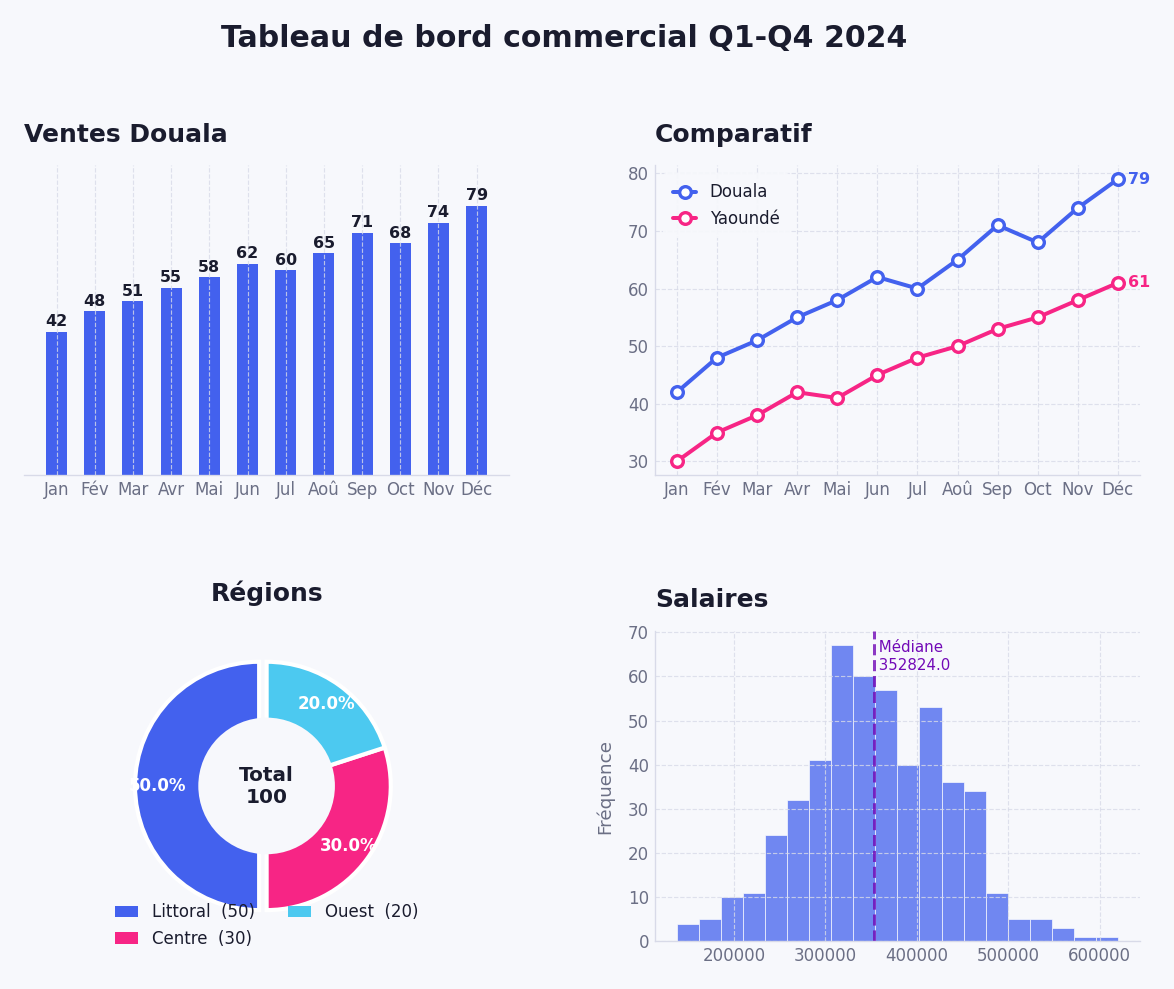

In [13]:
dashboard([
    {"type": "barres", "categories": mois, "valeurs": ventes_douala, "titre": "Ventes Douala"},
    {"type": "ligne", "x": mois, "y_series": {"Douala": ventes_douala, "Yaoundé": ventes_yaounde}, "titre": "Comparatif"},
    {"type": "camembert", "labels": ["Littoral", "Centre", "Ouest"], "valeurs": [50, 30, 20], "titre": "Régions"},
    {"type": "histogramme", "data": salaires, "titre": "Salaires"},
], titre_global="Tableau de bord commercial Q1-Q4 2024", ncols=2)
plt.show()


### Tracer dans un axe existant — `ax=...`

Toutes les fonctions ci-dessus acceptent un paramètre optionnel `ax`. Utile pour composer
plusieurs graphiques `beau_graphique` dans une figure matplotlib que vous contrôlez vous-même.

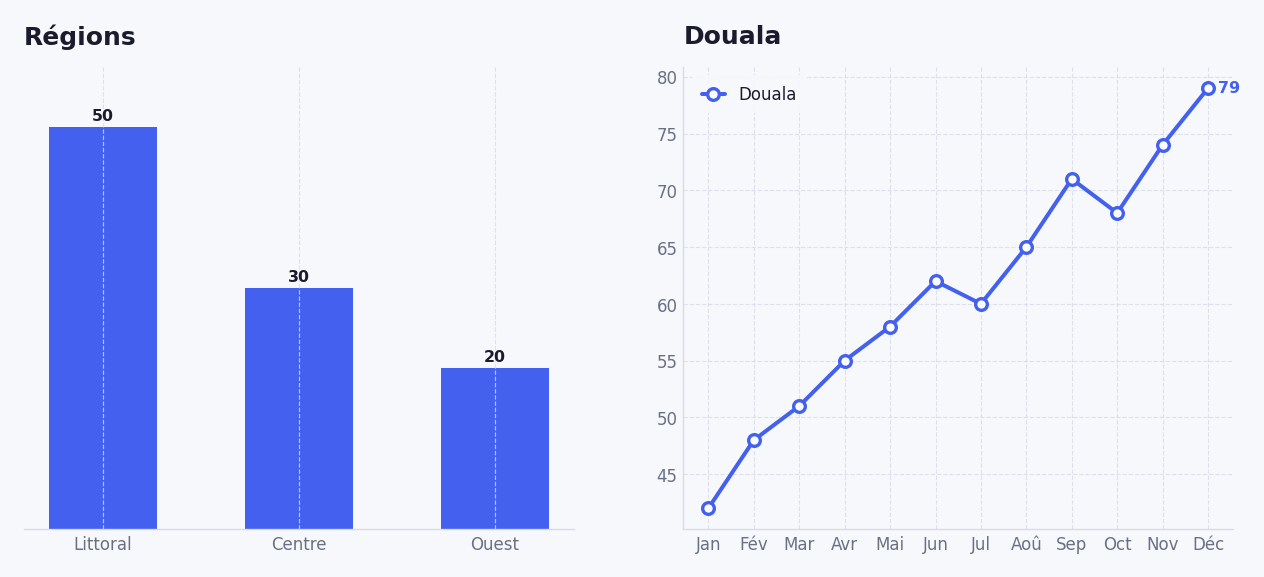

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
barres(["Littoral", "Centre", "Ouest"], [50, 30, 20], ax=axes[0], titre="Régions")
ligne(mois, {"Douala": ventes_douala}, ax=axes[1], titre="Douala")
plt.show()


### Dates automatiques sur l'axe X

Quand `x` contient des dates réelles (`datetime`, `pandas.Timestamp`...), l'axe est formaté
automatiquement (labels lisibles + rotation). Les libellés textuels (`"Jan"`, `"T1"`) restent
traités comme des catégories — aucun parsing de chaîne n'est tenté.

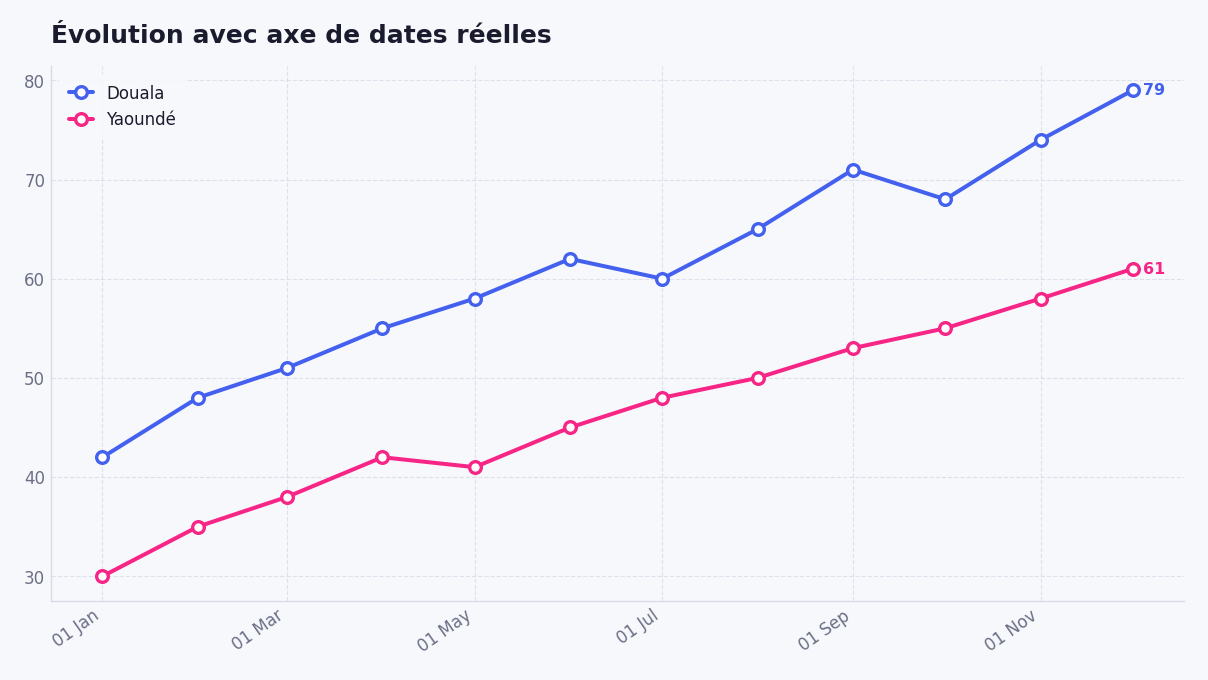

In [15]:
ligne(
    x=df["Date"].tolist(),
    y_series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    titre="Évolution avec axe de dates réelles",
)
plt.show()


### Graphiques McKinsey

Quatre graphiques inspirés des publications McKinsey : comparaison multi-dimensions entre deux périodes, scatter à 4 variables, proportions/ratios en carrés, et barres chronologiques connectées (`barres_connectees()`, présentée en section 3 — elle vit dans `narratif.py`).

### `dot_plot_comparatif()`

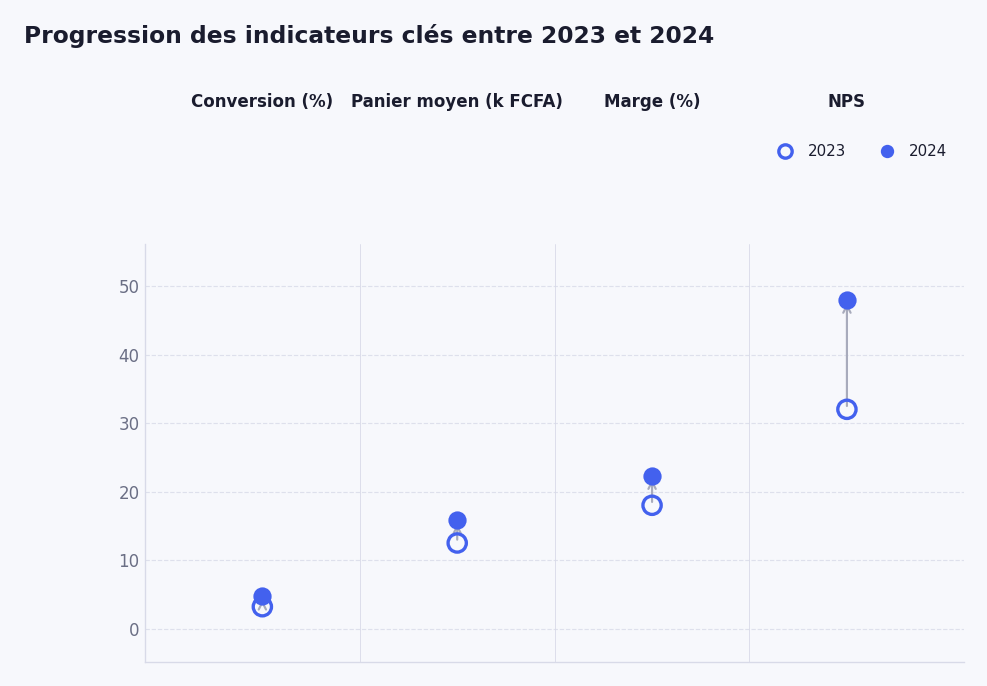

In [16]:
dot_plot_comparatif(
    colonnes={
        "Conversion (%)": (3.2, 4.7),
        "Panier moyen (k FCFA)": (12.5, 15.8),
        "Marge (%)": (18.0, 22.3),
        "NPS": (32, 48),
    },
    label_avant="2023", label_apres="2024",
    titre="Progression des indicateurs clés entre 2023 et 2024",
)
plt.show()

### `bulle_4d()`

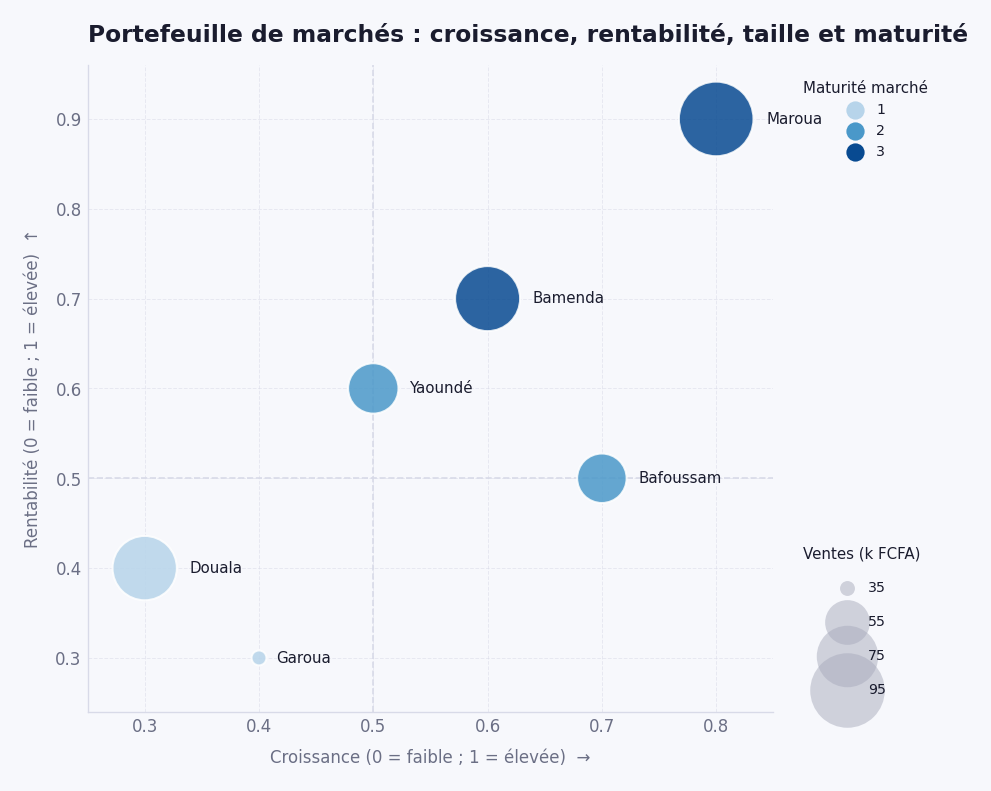

In [17]:
bulle_4d(
    x=[0.3, 0.5, 0.7, 0.4, 0.6, 0.8],
    y=[0.4, 0.6, 0.5, 0.3, 0.7, 0.9],
    taille=[ventes_douala[-1], ventes_yaounde[-1], 60, 35, 80, 95],
    couleur_var=[1, 2, 2, 1, 3, 3],
    labels=["Douala", "Yaoundé", "Bafoussam", "Garoua", "Bamenda", "Maroua"],
    xlabel="Croissance (0 = faible ; 1 = élevée)",
    ylabel="Rentabilité (0 = faible ; 1 = élevée)",
    label_taille="Ventes (k FCFA)",
    label_couleur="Maturité marché",
    quadrants=True,
    titre="Portefeuille de marchés : croissance, rentabilité, taille et maturité",
)
plt.show()

### `unit_chart()`

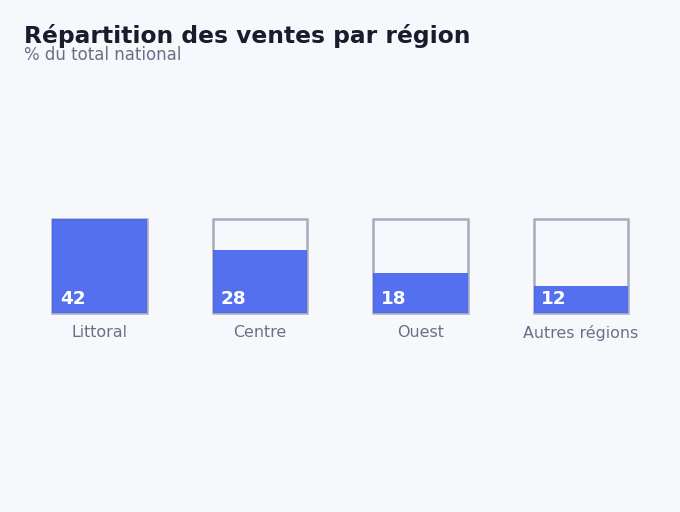

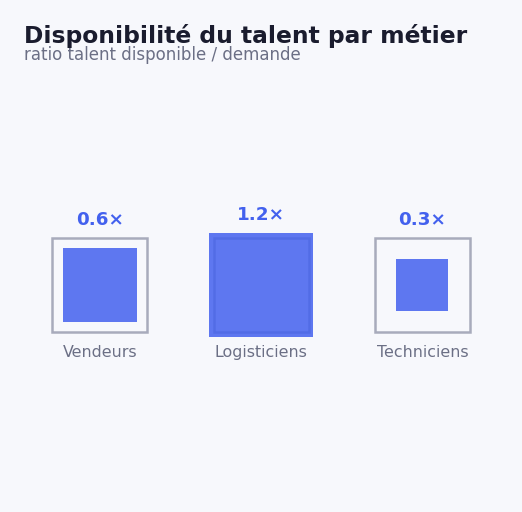

In [18]:
unit_chart(
    categories=["Littoral", "Centre", "Ouest", "Autres régions"],
    valeurs=[42, 28, 18, 12],
    mode="proportion",
    titre="Répartition des ventes par région",
    sous_titre="% du total national",
)
plt.show()

unit_chart(
    categories=["Vendeurs", "Logisticiens", "Techniciens"],
    valeurs=[0.6, 1.2, 0.3],
    mode="ratio",
    titre="Disponibilité du talent par métier",
    sous_titre="ratio talent disponible / demande",
)
plt.show()

### Nouveaux types (Phase 2) — distributions, contributions, comparaisons

Voir [`GUIDE_CHOIX.md`](GUIDE_CHOIX.md) pour savoir laquelle de ces fonctions choisir selon le message à transmettre.

### `box_plot()` et `violin()`

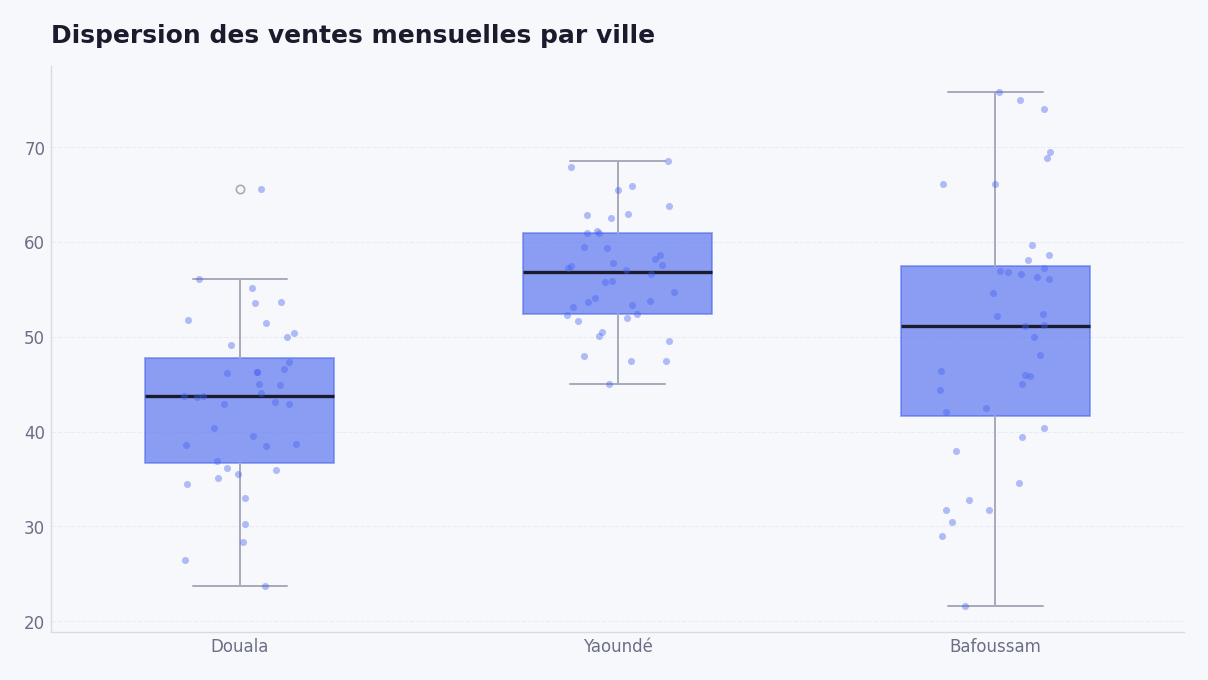

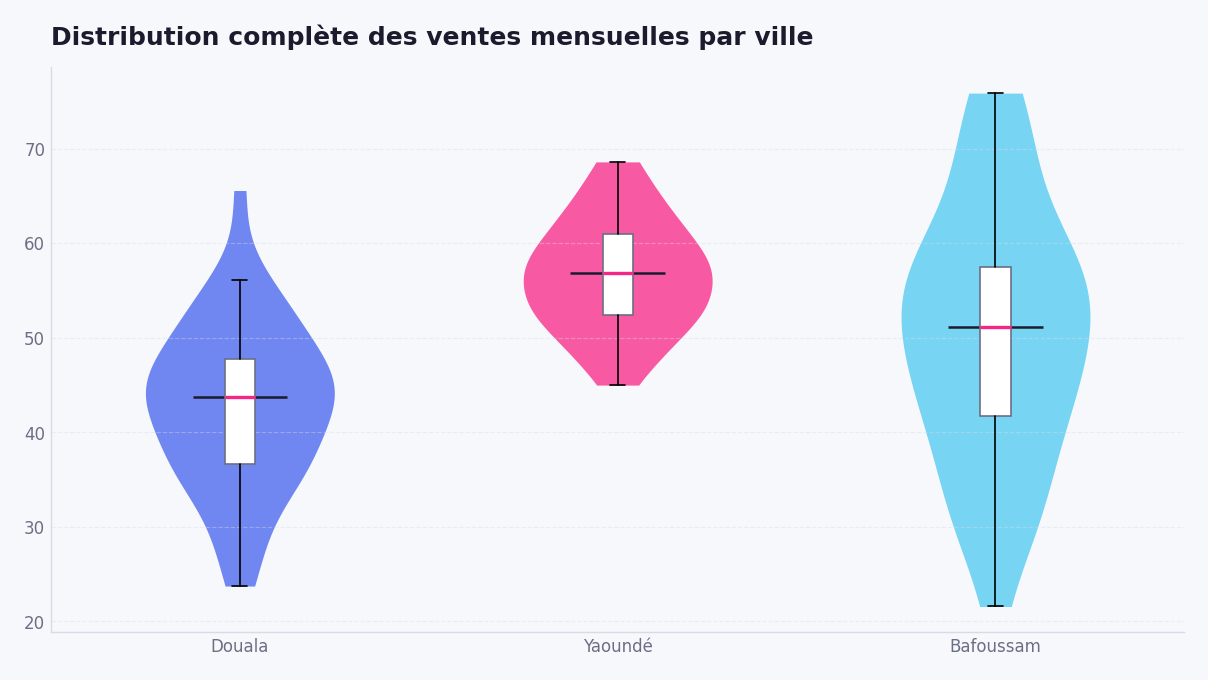

In [19]:
echantillons = [
    np.random.normal(45, 8, 40),
    np.random.normal(58, 6, 40),
    np.random.normal(50, 12, 40),
]
villes = ["Douala", "Yaoundé", "Bafoussam"]

box_plot(
    data=echantillons,
    categories=villes,
    afficher_points=True,
    titre="Dispersion des ventes mensuelles par ville",
)
plt.show()

violin(
    data=echantillons,
    categories=villes,
    titre="Distribution complète des ventes mensuelles par ville",
)
plt.show()

### `waterfall()`

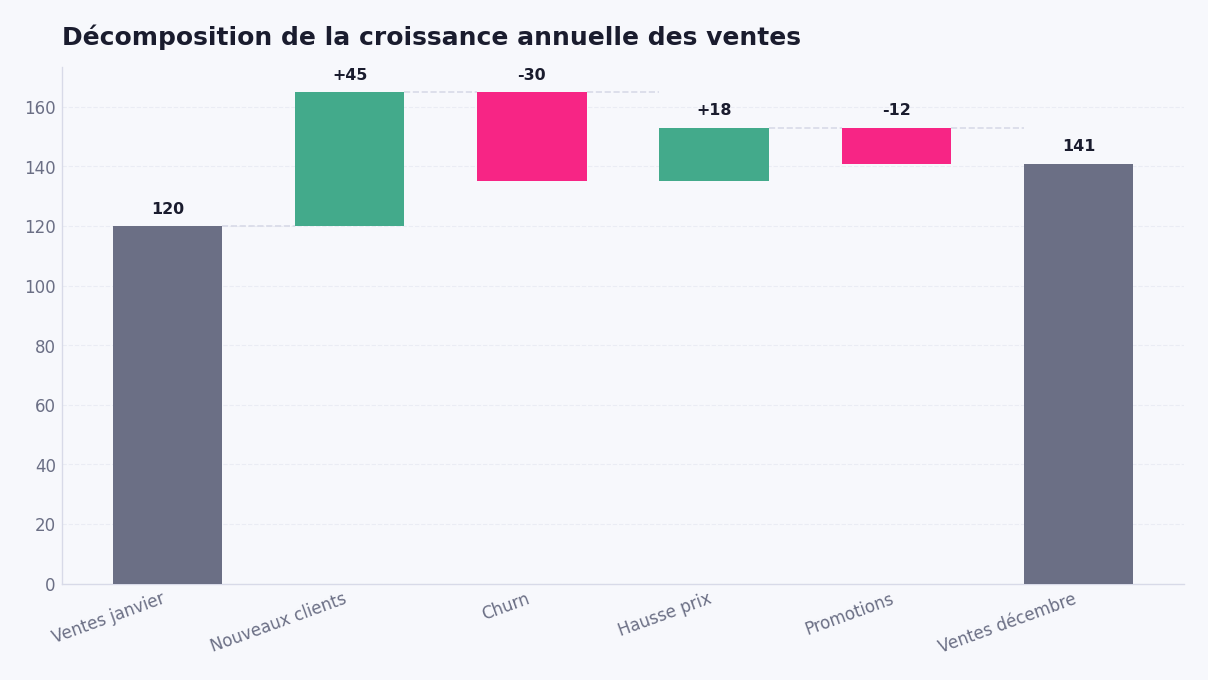

In [20]:
waterfall(
    categories=["Nouveaux clients", "Churn", "Hausse prix", "Promotions"],
    valeurs=[45, -30, 18, -12],
    total_debut=120,
    label_debut="Ventes janvier",
    label_fin="Ventes décembre",
    titre="Décomposition de la croissance annuelle des ventes",
)
plt.show()

### `lollipop()`

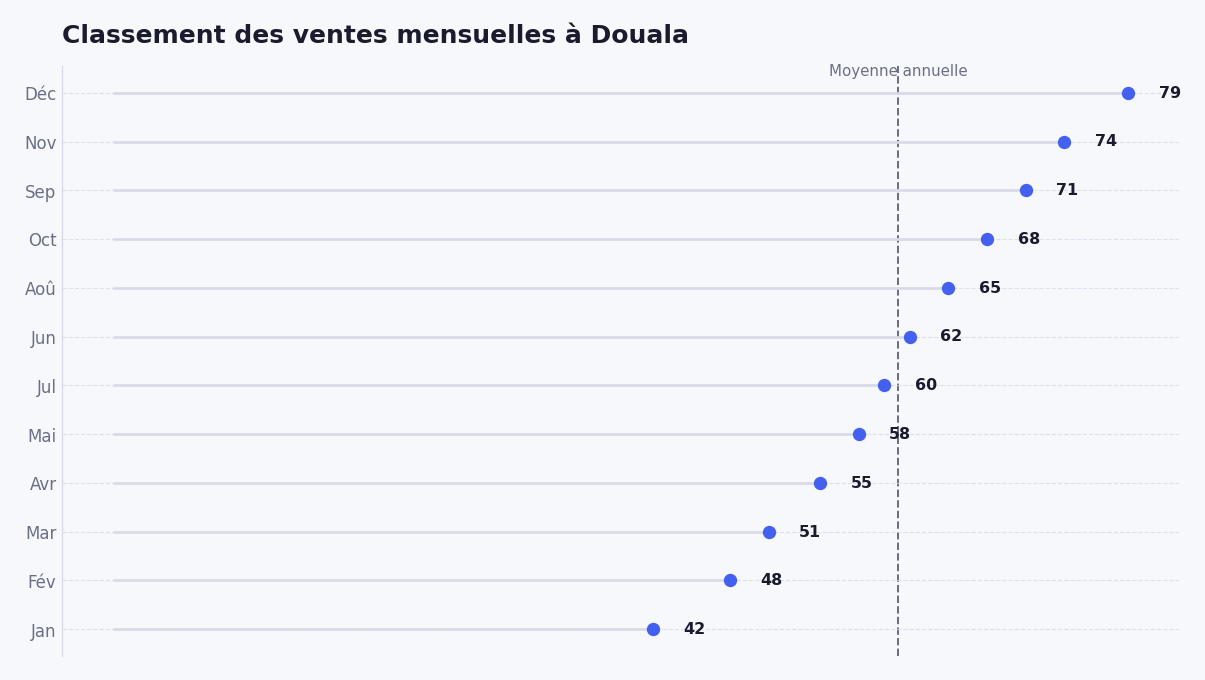

In [21]:
lollipop(
    categories=mois,
    valeurs=ventes_douala,
    ligne_ref=float(np.mean(ventes_douala)),
    label_ref="Moyenne annuelle",
    titre="Classement des ventes mensuelles à Douala",
)
plt.show()

### `slope()`

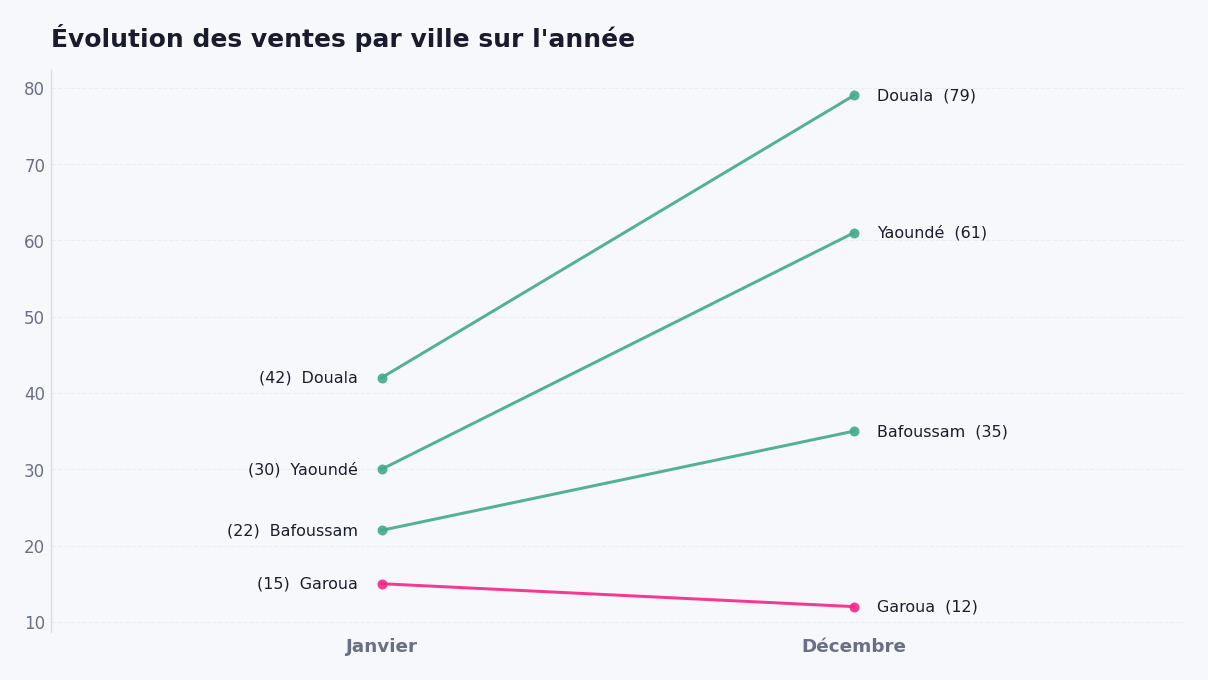

In [22]:
slope(
    categories=["Douala", "Yaoundé", "Bafoussam", "Garoua"],
    valeurs_gauche=[42, 30, 22, 15],
    valeurs_droite=[79, 61, 35, 12],
    label_gauche="Janvier", label_droite="Décembre",
    titre="Évolution des ventes par ville sur l\'année",
)
plt.show()

### `facet()`

C:\Users\jean luc\Documents\orange\beau_viz\src\beau_graphique\beau_graphique.py:1722: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


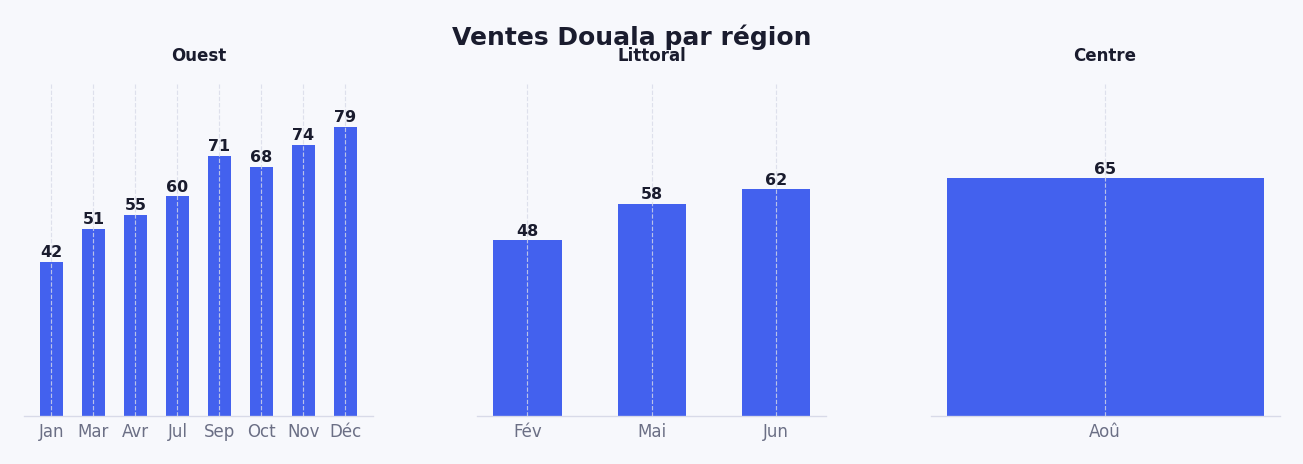

In [23]:
facet(
    df,
    x="Mois", y="Ventes_Douala", par="Region",
    type_graphique="barres",
    titre="Ventes Douala par région",
)
plt.show()

## 3. `narratif.py` — hiérarchie visuelle & annotations

### `barres_focus()`

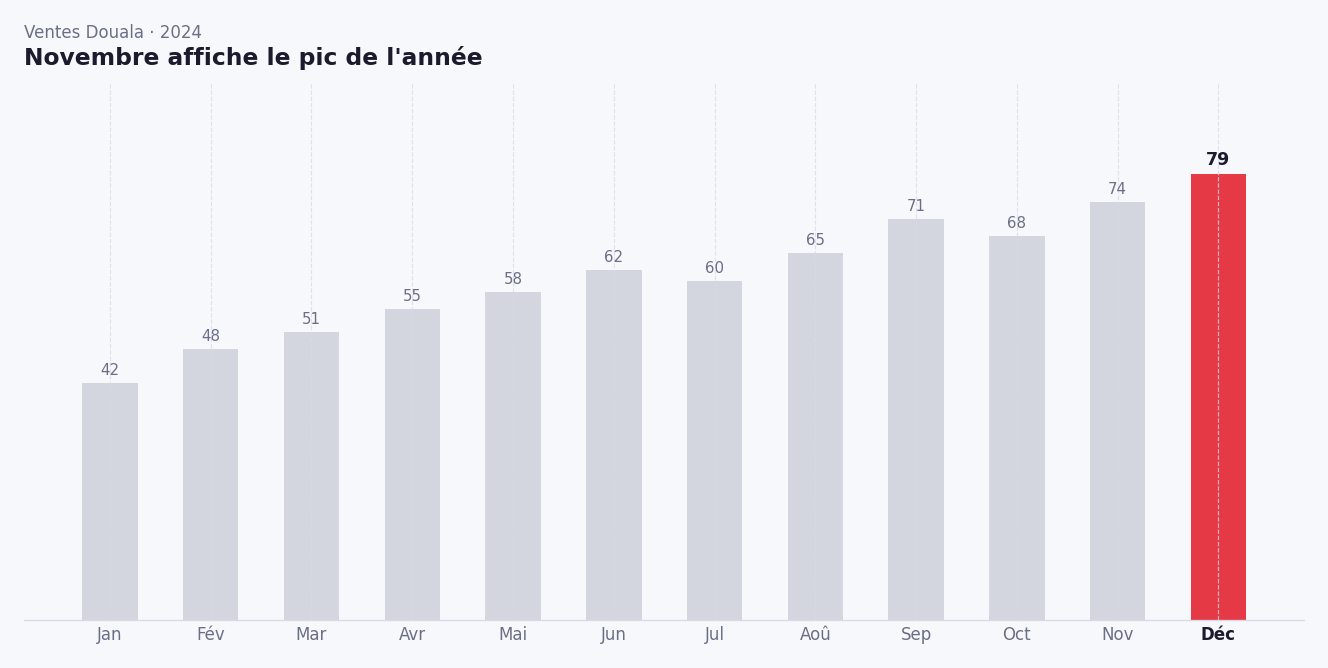

In [24]:
fig, ax = barres_focus(
    categories=mois,
    valeurs=ventes_douala,
    focus=int(np.argmax(ventes_douala)),
    titre="Novembre affiche le pic de l'année",
    sous_titre="Ventes Douala · 2024",
    accent=ACCENTS["rouge"],
)
plt.show()


### `ligne_focus()`

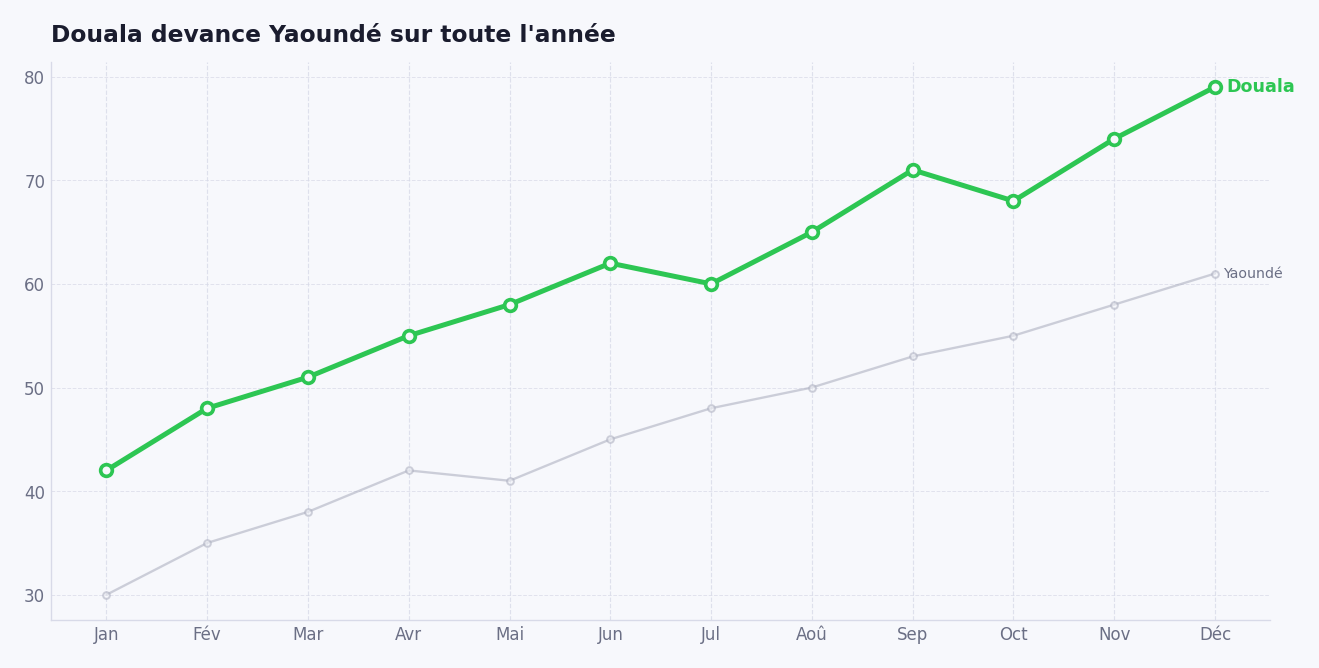

In [25]:
fig, ax = ligne_focus(
    x=mois,
    series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    focus_serie="Douala",
    titre="Douala devance Yaoundé sur toute l'année",
    accent=ACCENTS["vert"],
)
plt.show()


### `comparaison_avant_apres()`

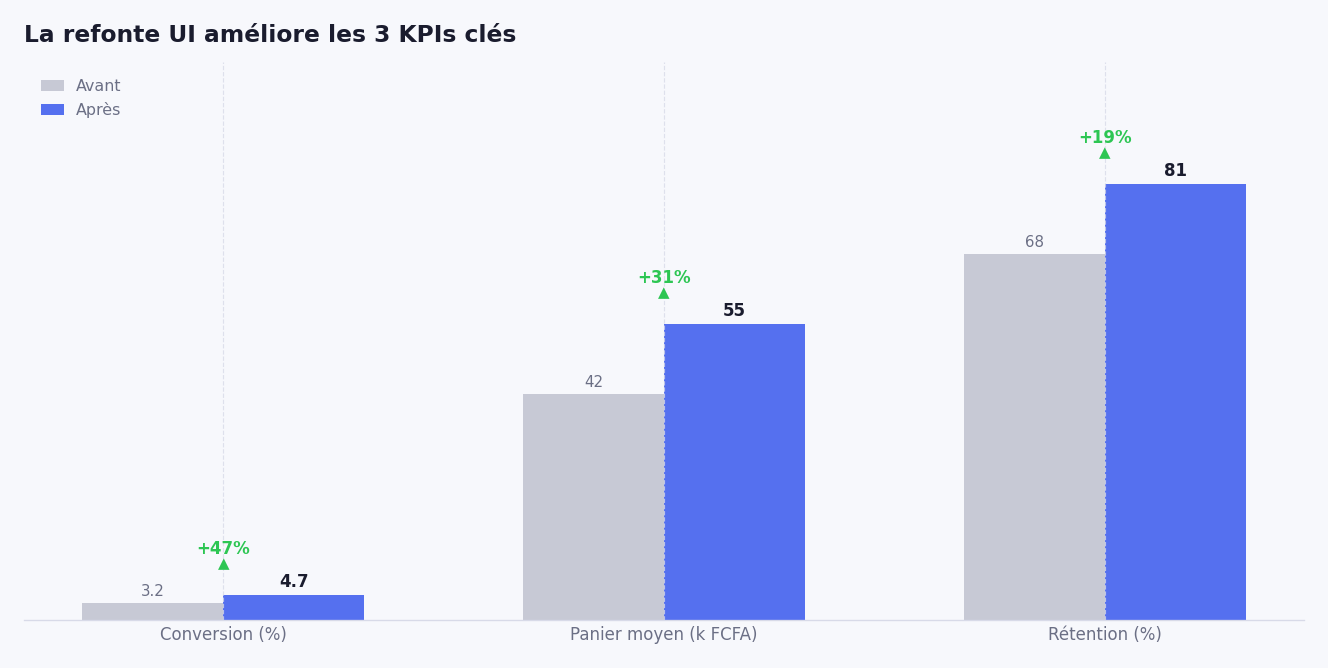

In [26]:
fig, ax = comparaison_avant_apres(
    categories=["Conversion (%)", "Panier moyen (k FCFA)", "Rétention (%)"],
    avant=[3.2, 42, 68],
    apres=[4.7, 55, 81],
    titre="La refonte UI améliore les 3 KPIs clés",
    accent=ACCENTS["bleu"],
)
plt.show()


### `barres_ranked()`

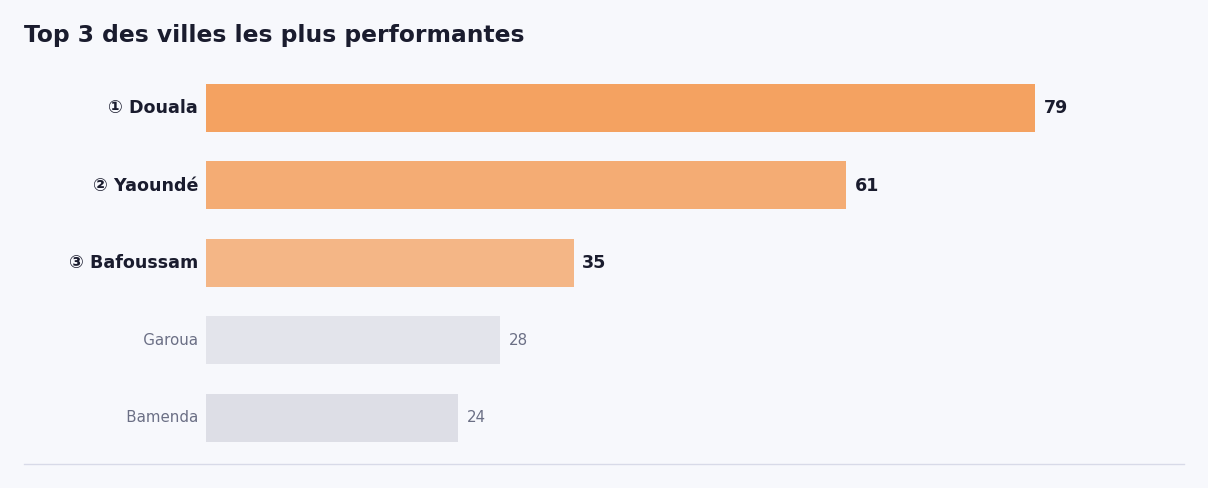

In [27]:
fig, ax = barres_ranked(
    categories=["Douala", "Yaoundé", "Bafoussam", "Garoua", "Bamenda"],
    valeurs=[79, 61, 35, 28, 24],
    titre="Top 3 des villes les plus performantes",
    top_n=3,
    accent=ACCENTS["or"],
)
plt.show()


### `divergent()`

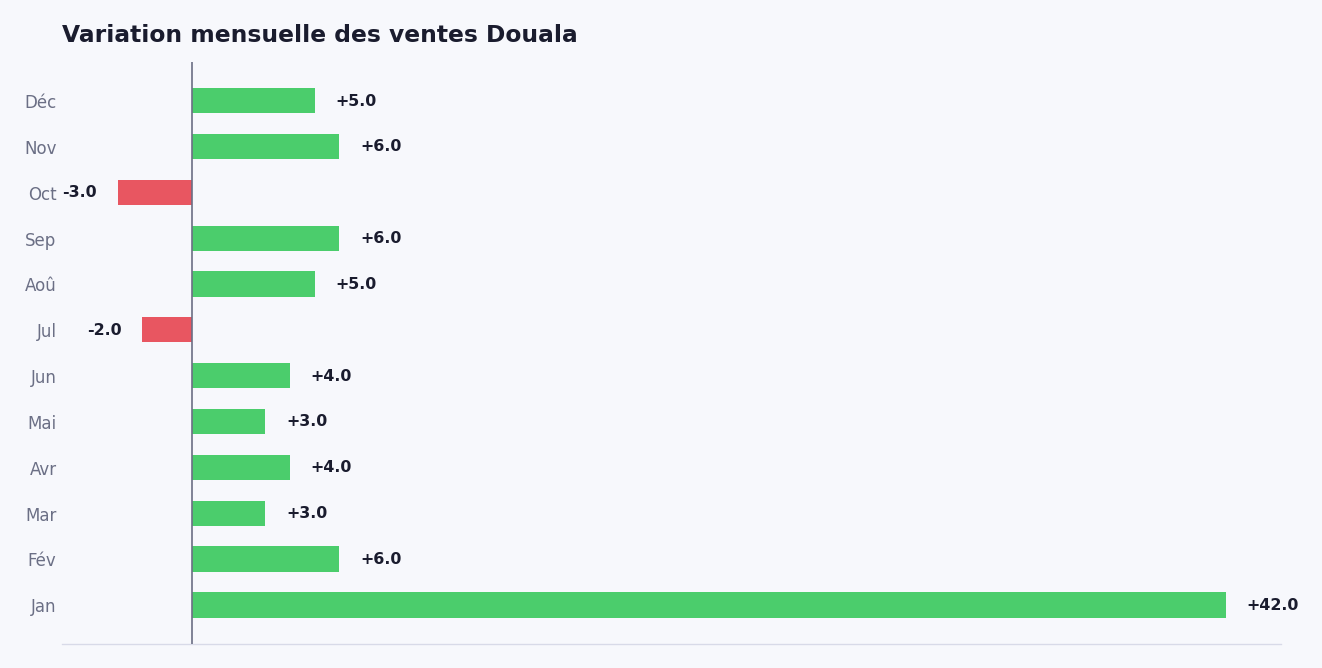

In [28]:
fig, ax = divergent(
    categories=mois,
    valeurs=list(np.diff([0] + ventes_douala)),
    titre="Variation mensuelle des ventes Douala",
)
plt.show()


### `bullet_chart()`

C:\Users\jean luc\Documents\orange\beau_viz\src\beau_graphique\narratif.py:566: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout(h_pad=0.4)


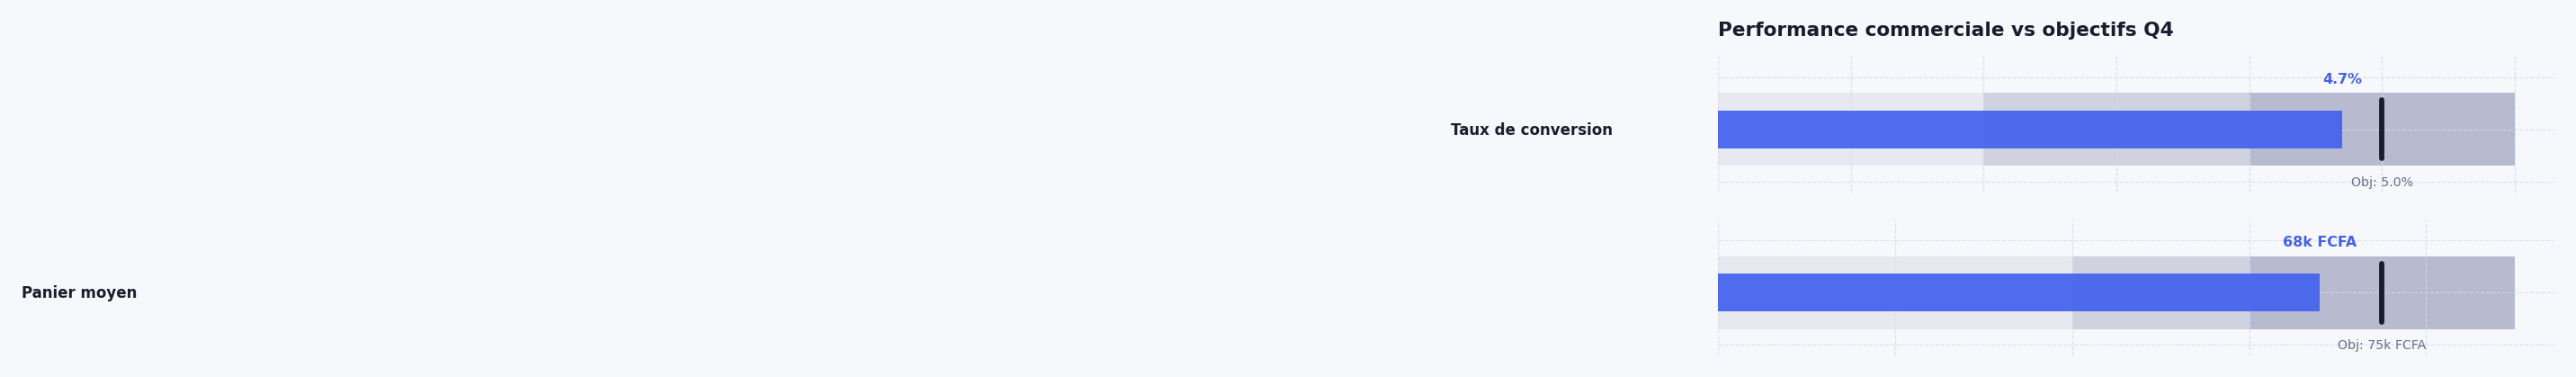

In [29]:
fig, axes = bullet_chart([
    {"nom": "Taux de conversion", "valeur": 4.7, "objectif": 5.0,
     "plages": [2, 4, 6], "fmt": "{:.1f}%"},
    {"nom": "Panier moyen", "valeur": 68, "objectif": 75,
     "plages": [40, 60, 90], "fmt": "{:.0f}k FCFA"},
], titre="Performance commerciale vs objectifs Q4")
plt.show()


### `barres_connectees()`

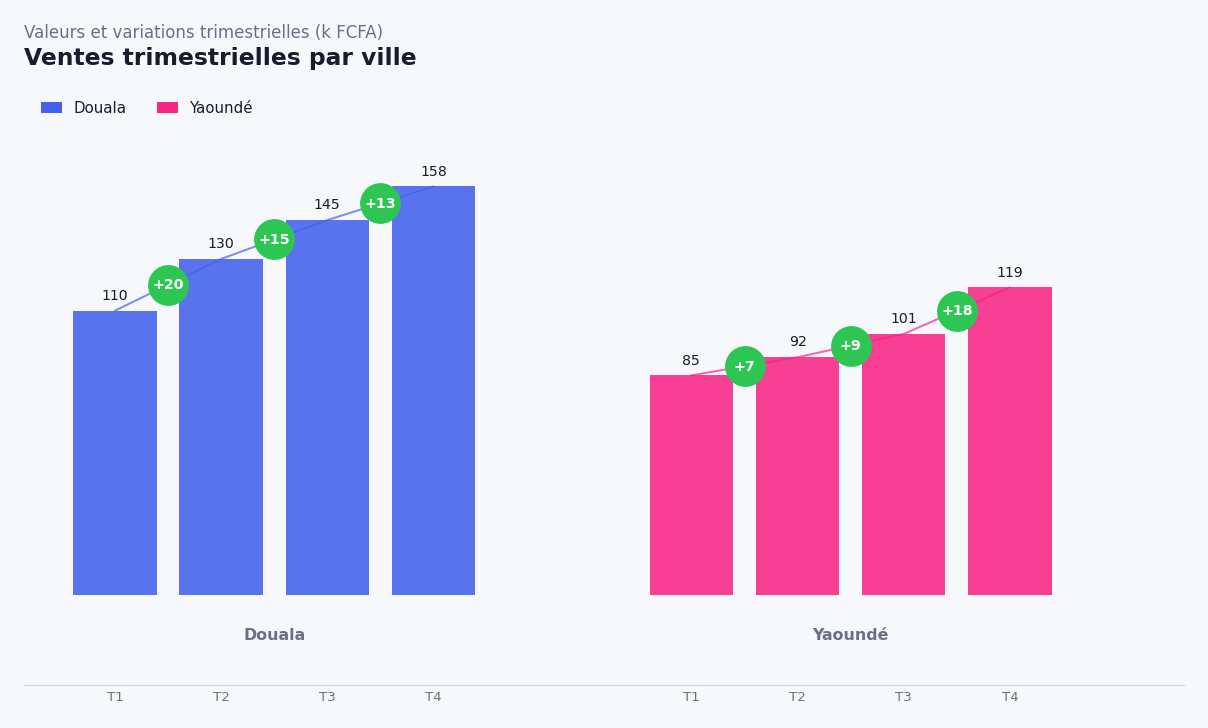

In [30]:
fig, ax = barres_connectees(
    categories=["Douala", "Yaoundé"],
    periodes=["T1", "T2", "T3", "T4"],
    valeurs=[
        [110, 130, 145, 158],
        [85, 92, 101, 119],
    ],
    titre="Ventes trimestrielles par ville",
    sous_titre="Valeurs et variations trimestrielles (k FCFA)",
)
plt.show()

### Annotations superposables

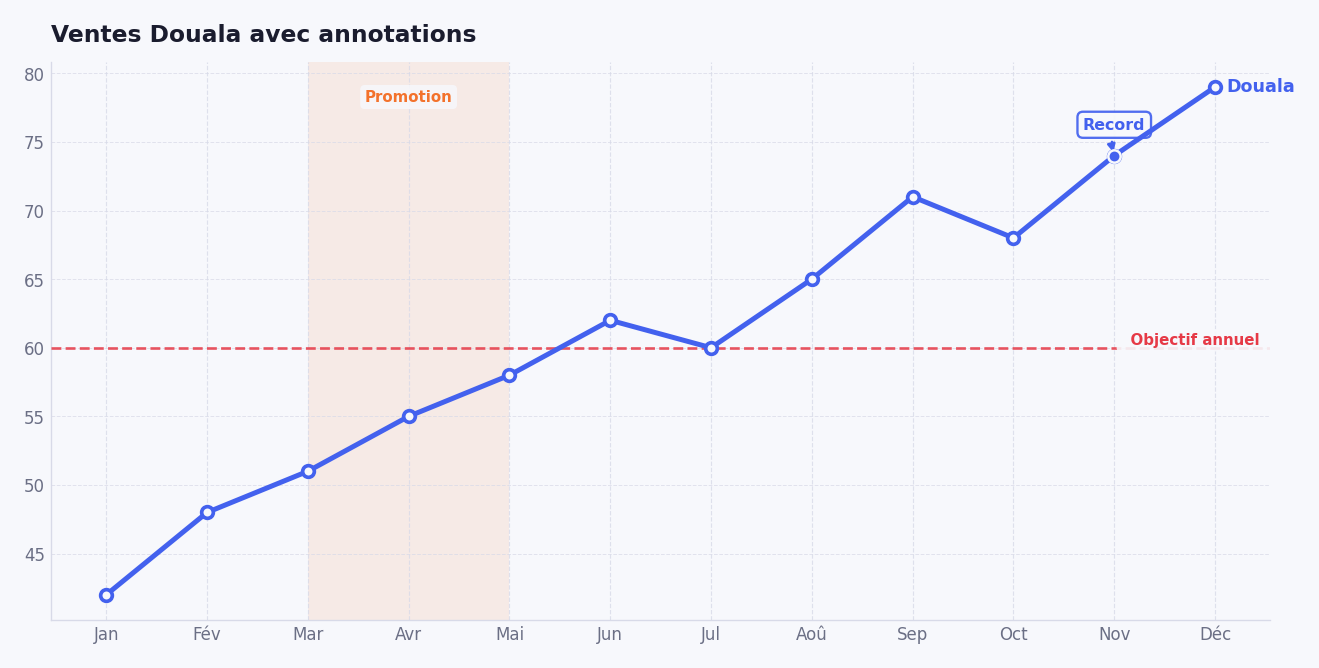

In [31]:
fig, ax = ligne_focus(
    x=mois, series={"Douala": ventes_douala}, focus_serie="Douala",
    titre="Ventes Douala avec annotations",
)
annoter_zone(ax, x_debut=2, x_fin=4, label="Promotion", couleur=ACCENTS["orange"])
annoter_seuil(ax, y=60, label="Objectif annuel")
annoter_point(ax, x=10, y=ventes_douala[10], label="Record", direction="haut")
plt.show()


## 4. `pipeline.py` — intégration DataFrame

### `inspecter()`

In [32]:
inspecter(df)


┌──────────────────────────────────────────────────────────┐
│  DataFrame — 12 lignes × 6 colonnes                      │
├──────────────────────────────────────────────────────────┤
│  Colonne                Type            NaN   Unique Plage / Exemples  │
├──────────────────────────────────────────────────────────┤
│  Mois                   object            —       12  Jan, Fév, Mar     │
│  Date                   datetime64[       —       12  2024-01-01 00:0…  │
│  Ventes_Douala          int64             —       12  42 → 79           │
│  Ventes_Yaounde         int64             —       12  30 → 61           │
│  Region                 object            —        3  Ouest, Littoral…  │
│  Marge_pct              float64           —       11  11.50 → 26.00      ⚡1│
├──────────────────────────────────────────────────────────┤
│  ✓ Complétude : 100.0%   NaN total : 0   Doublons : 0          │
│  Num : 3 col(s)   Cat : 3 col(s)                              │
└───────────────────────────

### `nettoyer()`

In [33]:
df_avec_nan = df.copy()
df_avec_nan.loc[2, "Marge_pct"] = np.nan
df_propre = nettoyer(df_avec_nan, dropna="fill", dedup=True, trier_par="Mois")


✓ nettoyer() — 12 lignes × 6 colonnes
  · NaN 'Marge_pct' → médiane (19.90) ×1
  · trié par 'Mois'


### `depuis_df()` + wrappers `_df`

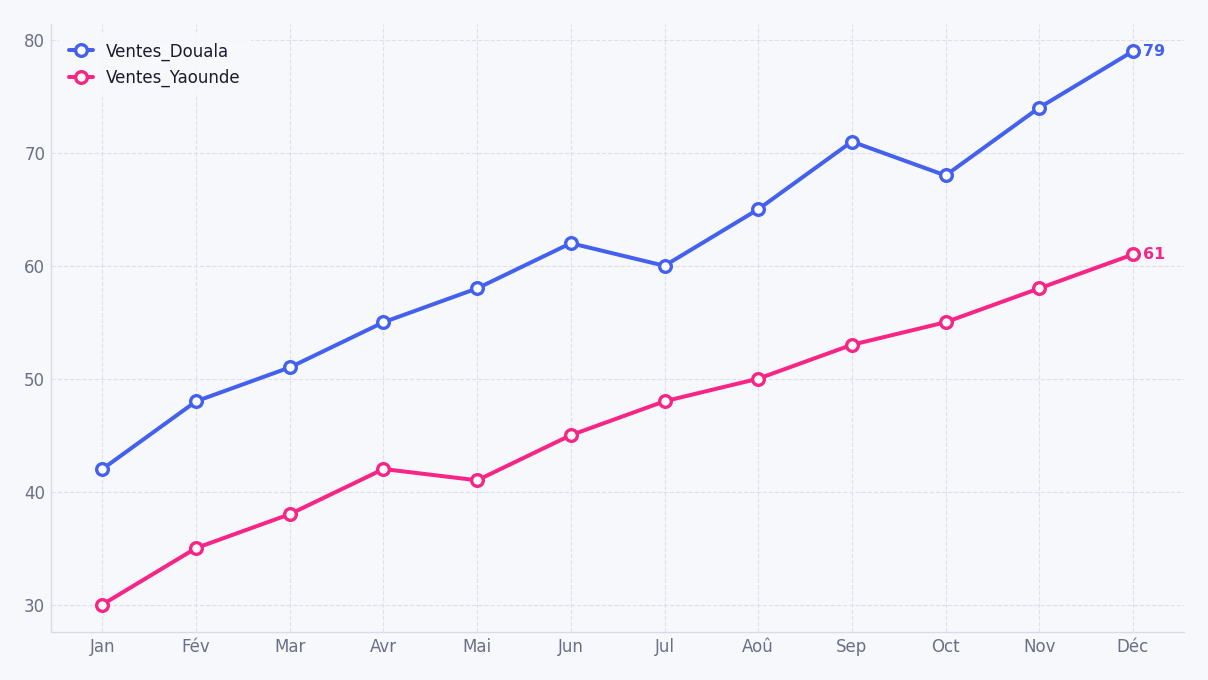

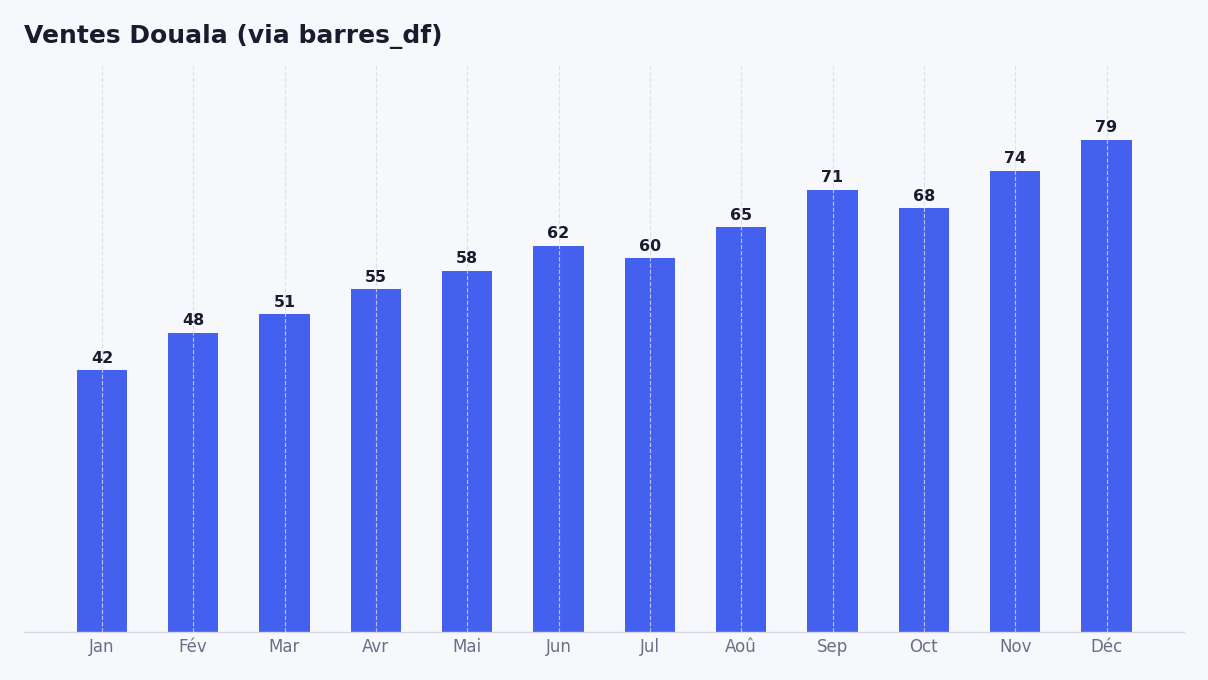

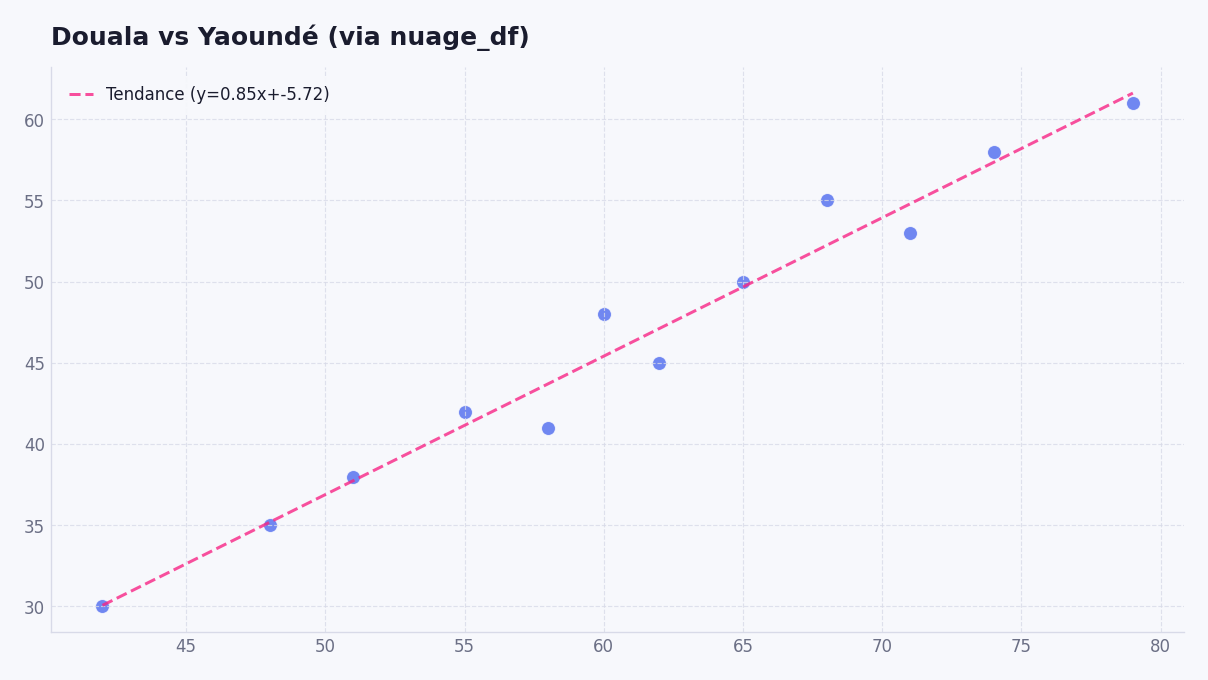

In [34]:
ligne(**depuis_df(df, x="Mois", y=["Ventes_Douala", "Ventes_Yaounde"]))
plt.show()

barres_df(df, x="Mois", y="Ventes_Douala", titre="Ventes Douala (via barres_df)")
plt.show()

nuage_df(df, x="Ventes_Douala", y="Ventes_Yaounde", ligne_tendance=True,
         titre="Douala vs Yaoundé (via nuage_df)")
plt.show()


## 5. `themes.py` — thèmes et palettes

In [35]:
lister()


┌────────────────────────────────────────────────────────────┐
│  Thèmes disponibles                                        │
├────────────────────────────────────────────────────────────┤
│  defaut                 Palette bleue-rose vive, fond  ◀ actif│
│  finance                Palette sobre et professionnel        │
│  sante                  Teintes médicales claires — bl        │
│  academique             Sobre pour publications — 8 co        │
│  tech                   Néon contrôlé sur fond sombre         │
│  minimal                Gris + 1 accent — pour rapport        │
│  chaud                  Tonalités ambre et corail — sl        │
│  sombre                 Fond noir profond, palette viv        │
│  daltonisme_safe        Palette Wong (2011) — distingu        │
│  deuteranopie           Optimisée rouge-vert (8 % des         │
│  sequentielle_bleu      Dégradé clair→foncé pour une v        │
│  divergente             Rouge → blanc → bleu — pour de        │
└──────────────────

✓ Thème 'Finance' activé ☀


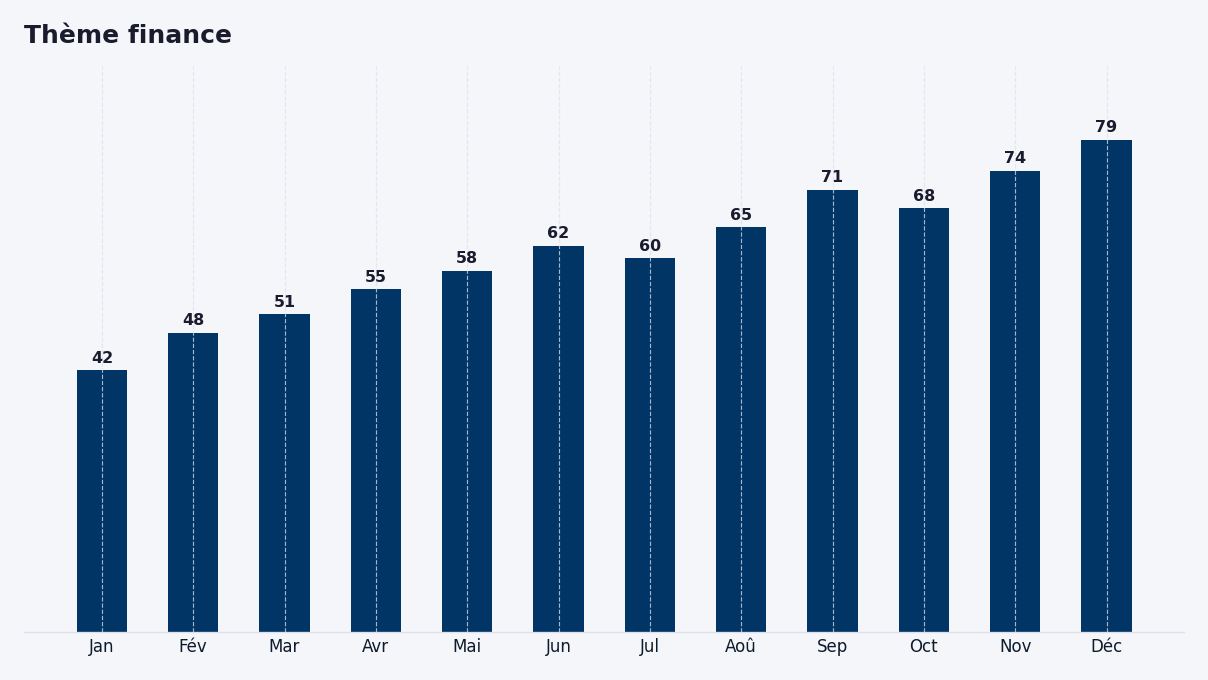

✓ Thème 'Sombre' activé 🌙


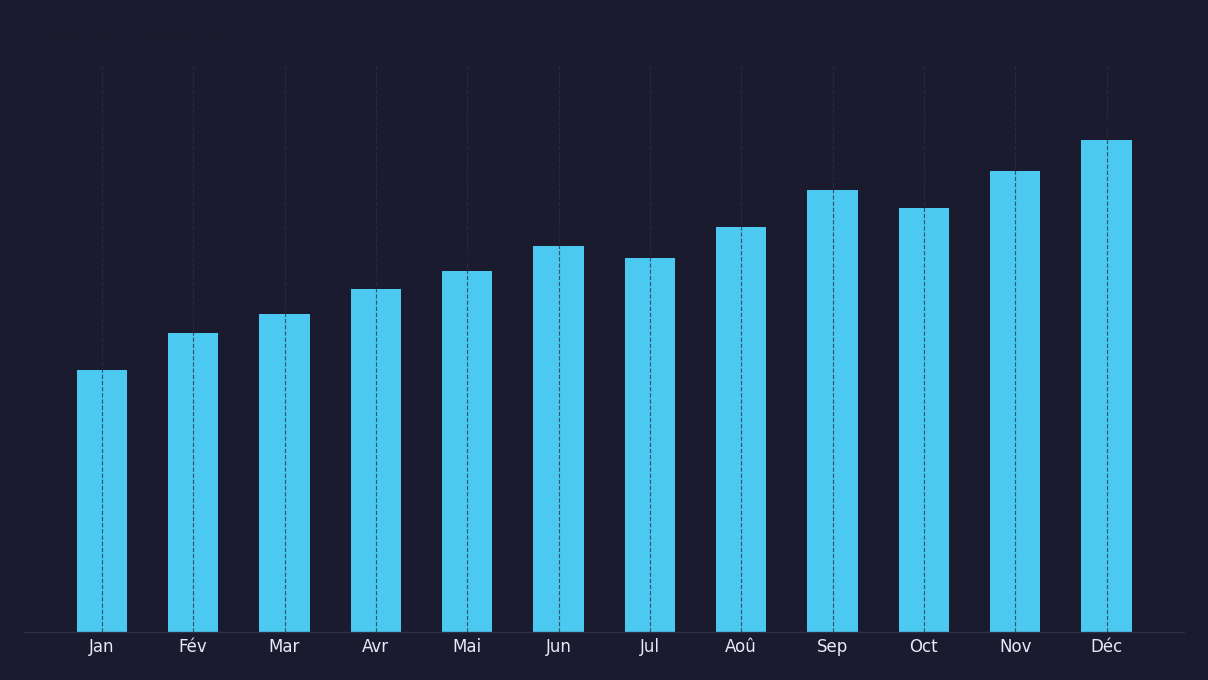

✓ Thème 'Défaut' activé ☀


In [36]:
appliquer("finance")
barres(mois, ventes_douala, titre="Thème finance")
plt.show()

appliquer("sombre")
barres(mois, ventes_douala, titre="Thème sombre")
plt.show()

reinitialiser()


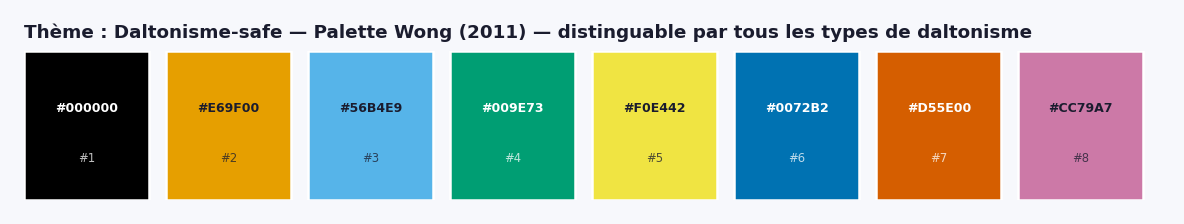

In [37]:
apercu("daltonisme_safe")
plt.show()


## 6. Phase 3 — Puissance maximale

Les fonctionnalités ci-dessous s'appliquent à **tous** les graphiques de la librairie. À lire après avoir vu les sections précédentes.

### 6.1 `format=` — presets de taille de figure

Au lieu de deviner le `figsize`, utilise un preset nommé. `figsize=` gagne toujours si les deux sont fournis.

| Preset | Taille (pouces) | Usage |
|---|---|---|
| `"slide"` | 13.33 × 7.5 | PowerPoint / Google Slides 16:9 |
| `"a4"` | 11.69 × 5.5 | Rapport Word / PDF demi-page |
| `"a4_pleine"` | 11.69 × 8.27 | PDF pleine page |
| `"carre"` | 7 × 7 | Réseaux sociaux, miniatures |
| `"large"` | 14 × 5.6 | Dashboard multi-graphiques |

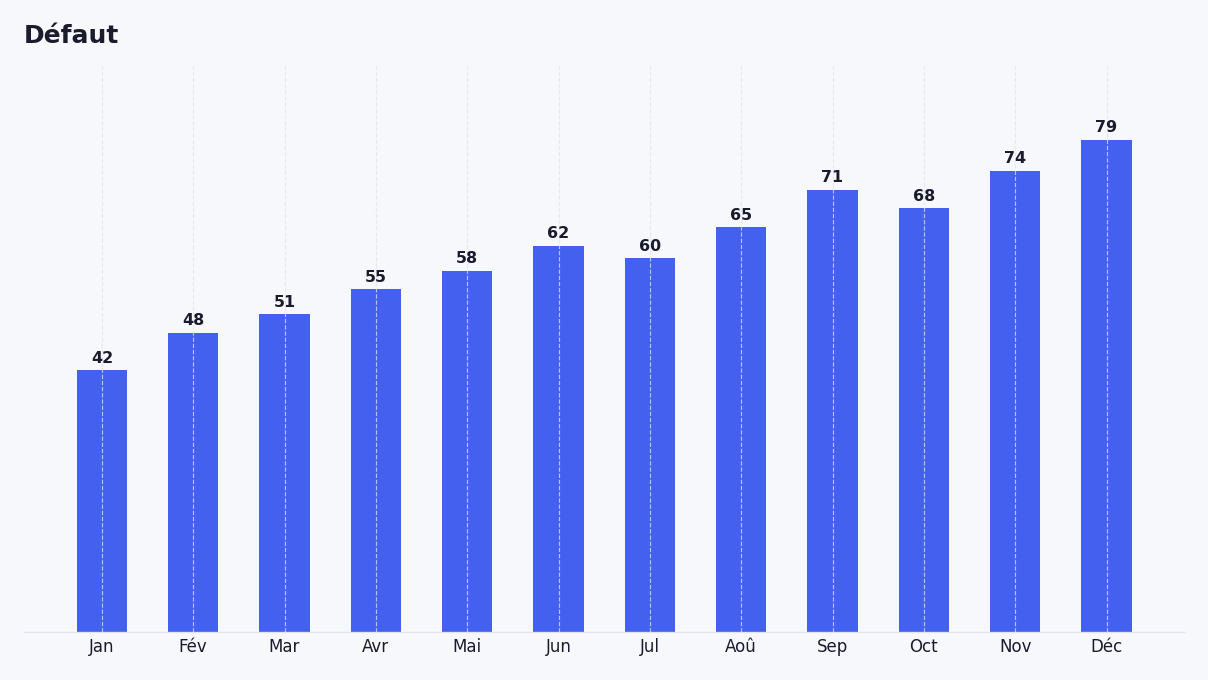

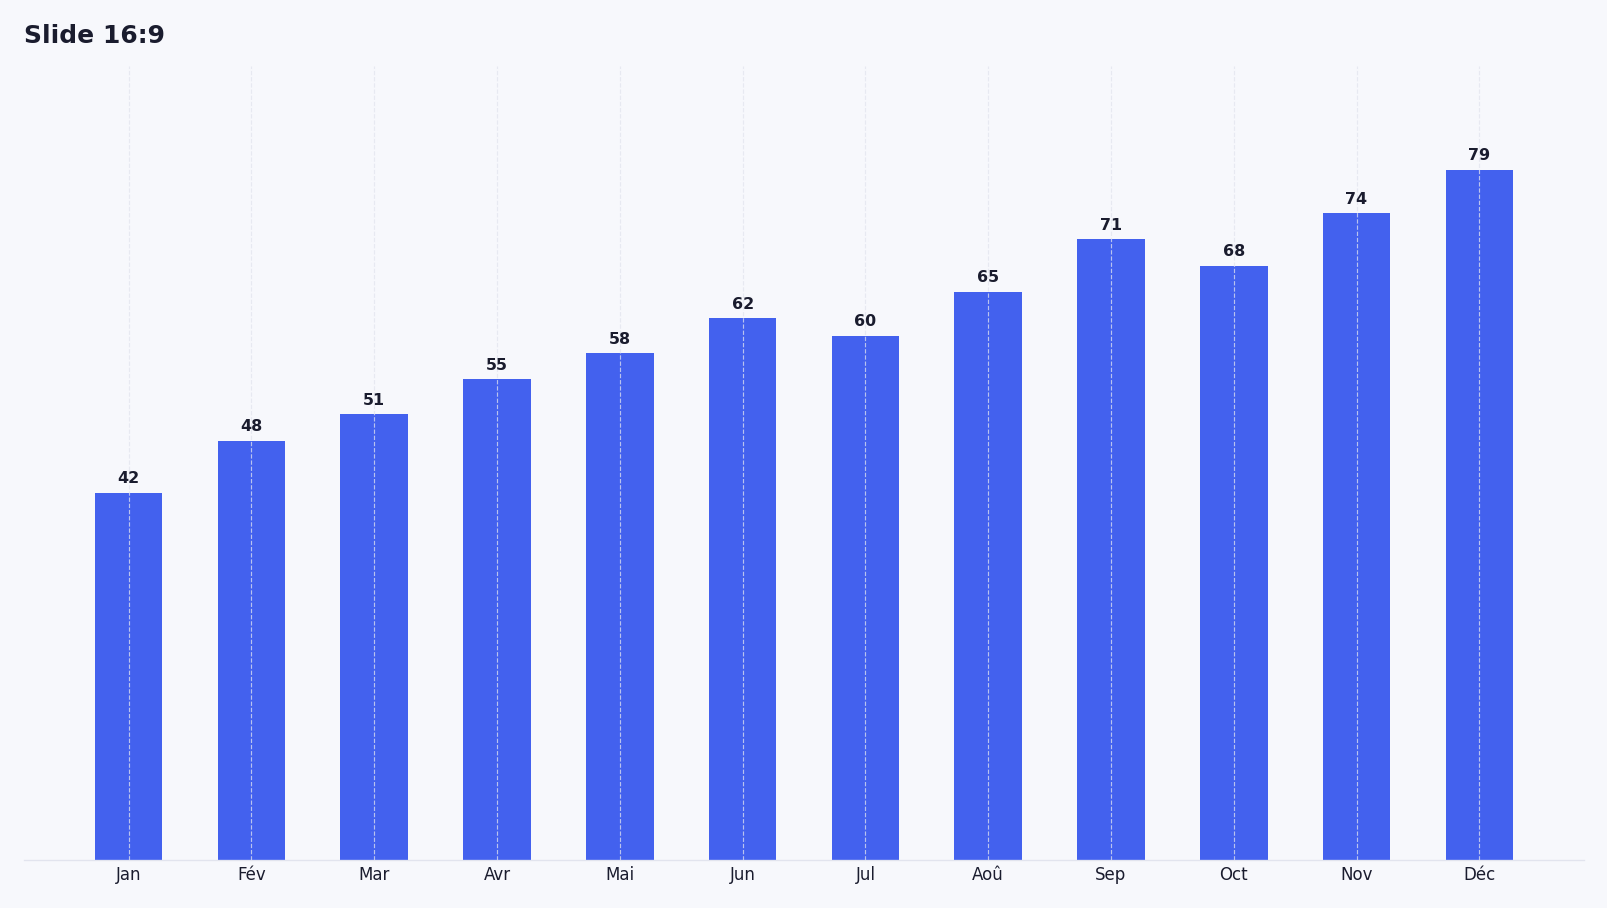

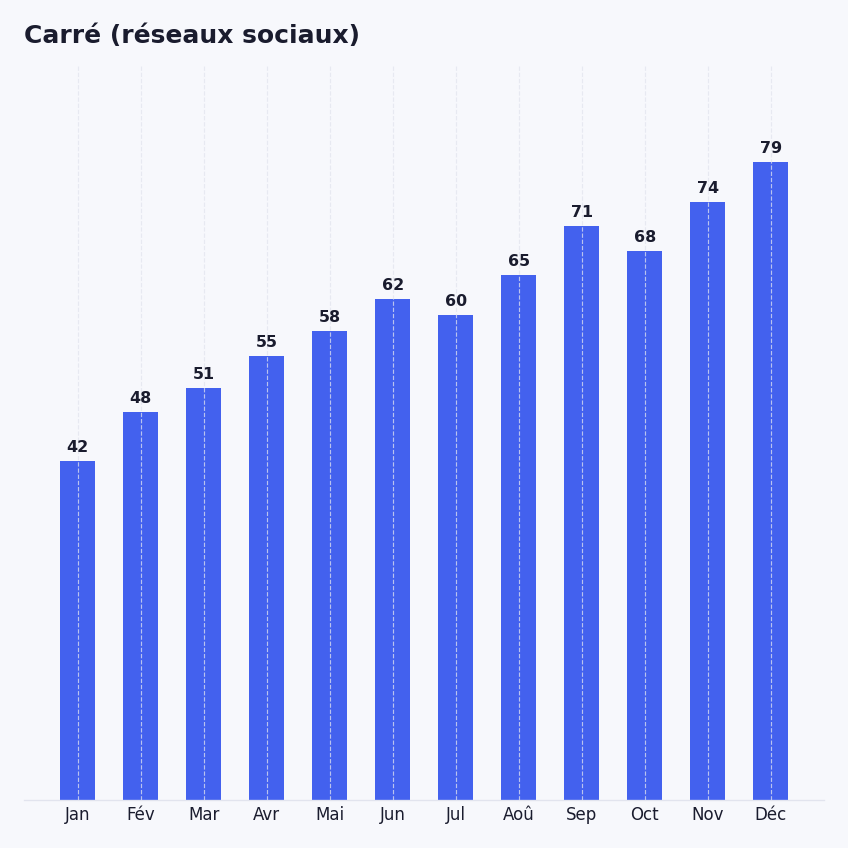

In [38]:
# Sans format= : figsize par défaut (10 × 5.6)
barres(mois, ventes_douala, titre="Défaut")
plt.show()

# Avec format= : preset nommé
barres(mois, ventes_douala, titre='Slide 16:9', format="slide")
plt.show()

barres(mois, ventes_douala, titre='Carré (réseaux sociaux)', format="carre")
plt.show()

### 6.2 `enregistrer_couleurs()` — cohérence des couleurs dans un rapport

Problème classique : Douala est bleu dans un graphique et rose dans le suivant. La solution : déclarer les couleurs une seule fois, elles s'appliquent partout automatiquement.

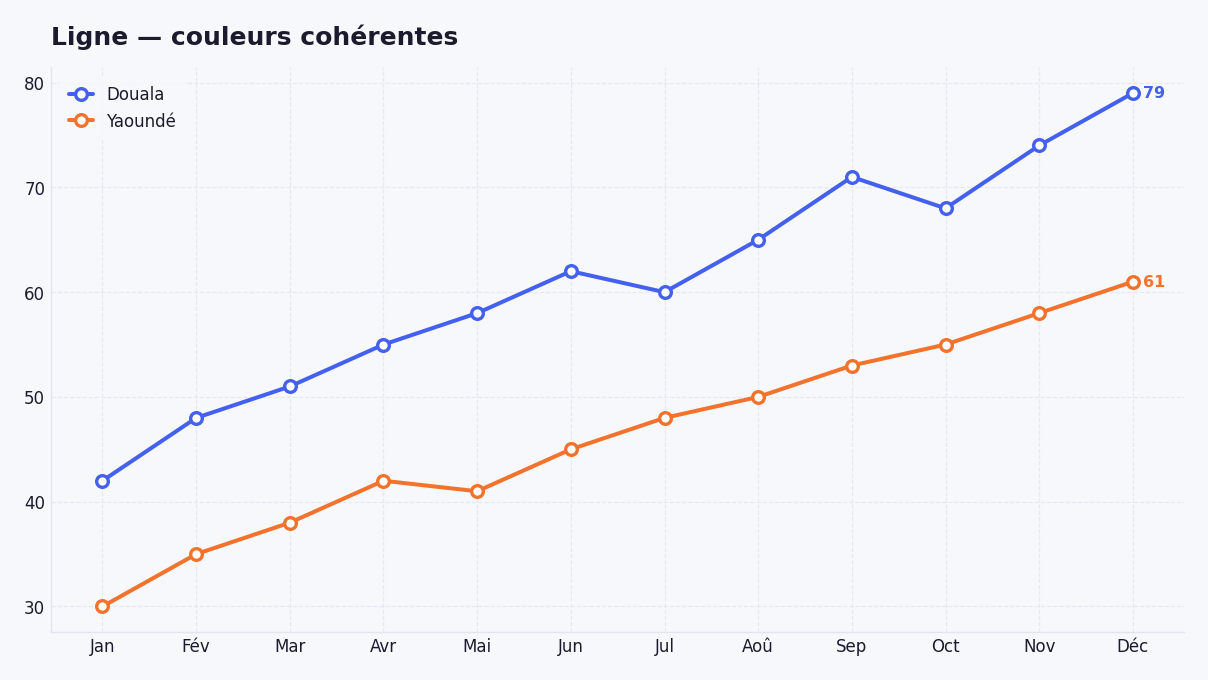

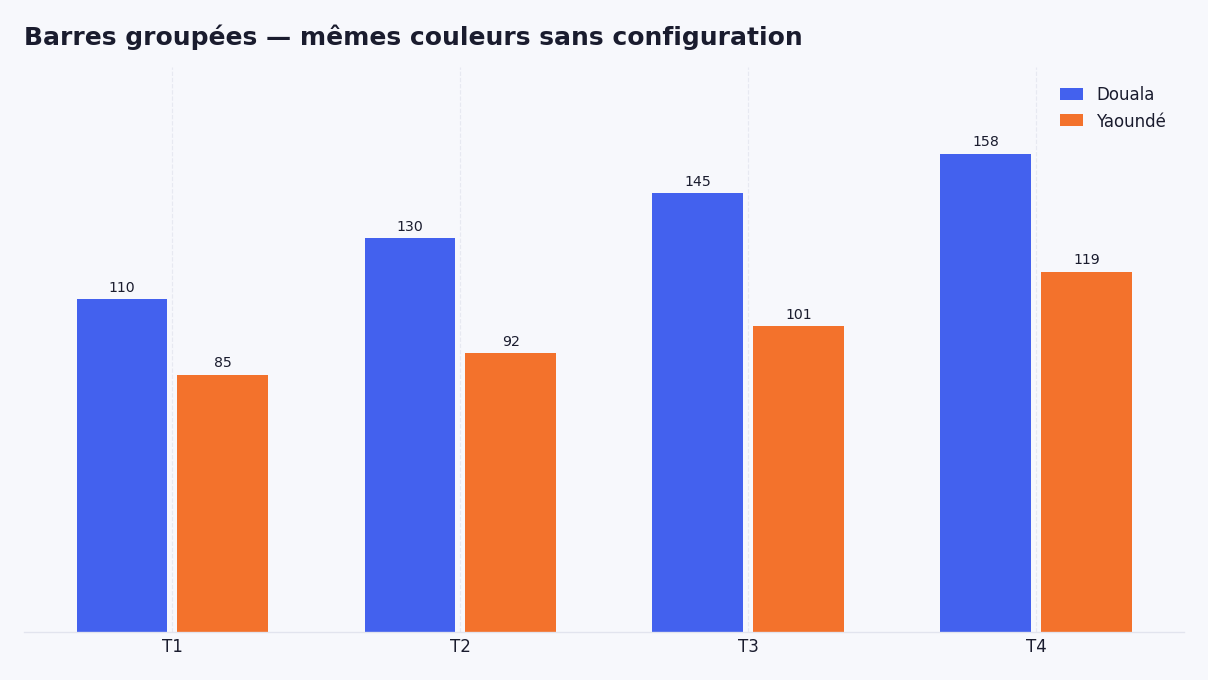

In [39]:
# Déclarer une fois en début de session
enregistrer_couleurs({
    "Douala":    "#4361EE",
    "Yaoundé":   "#F3722C",
    "Bafoussam": "#2DC653",
})

# Maintenant TOUS les graphiques utilisent ces couleurs automatiquement
ligne(
    x=mois,
    y_series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    titre="Ligne — couleurs cohérentes",
)
plt.show()

barres_groupees(
    categories=["T1", "T2", "T3", "T4"],
    groupes={"Douala": [110, 130, 145, 158], "Yaoundé": [85, 92, 101, 119]},
    titre="Barres groupées — mêmes couleurs sans configuration",
)
plt.show()

# Réinitialiser si besoin
reinitialiser_couleurs()

### 6.3 `fn_couleur=` — coloration conditionnelle

Colorie chaque barre ou point selon une règle métier, sans boucle manuelle.

**`colorier_si(seuil)`** → vert si au-dessus, rouge si en-dessous.
**`colorier_selon(règles)`** → liste de règles prioritaires (feu tricolore).

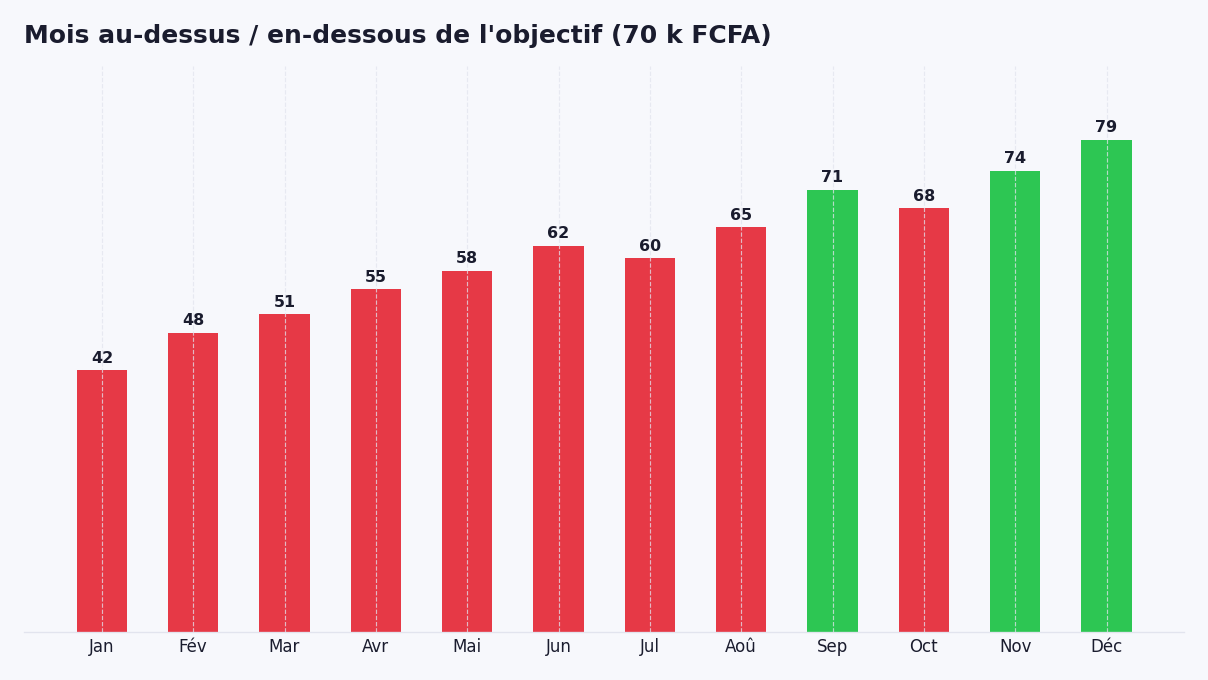

In [40]:
# colorier_si — seuil simple
barres(
    mois, ventes_douala,
    fn_couleur=colorier_si(seuil=70),   # vert > 70, rouge < 70
    titre="Mois au-dessus / en-dessous de l'objectif (70 k FCFA)",
    valeurs_sur_barres=True,
)
plt.show()

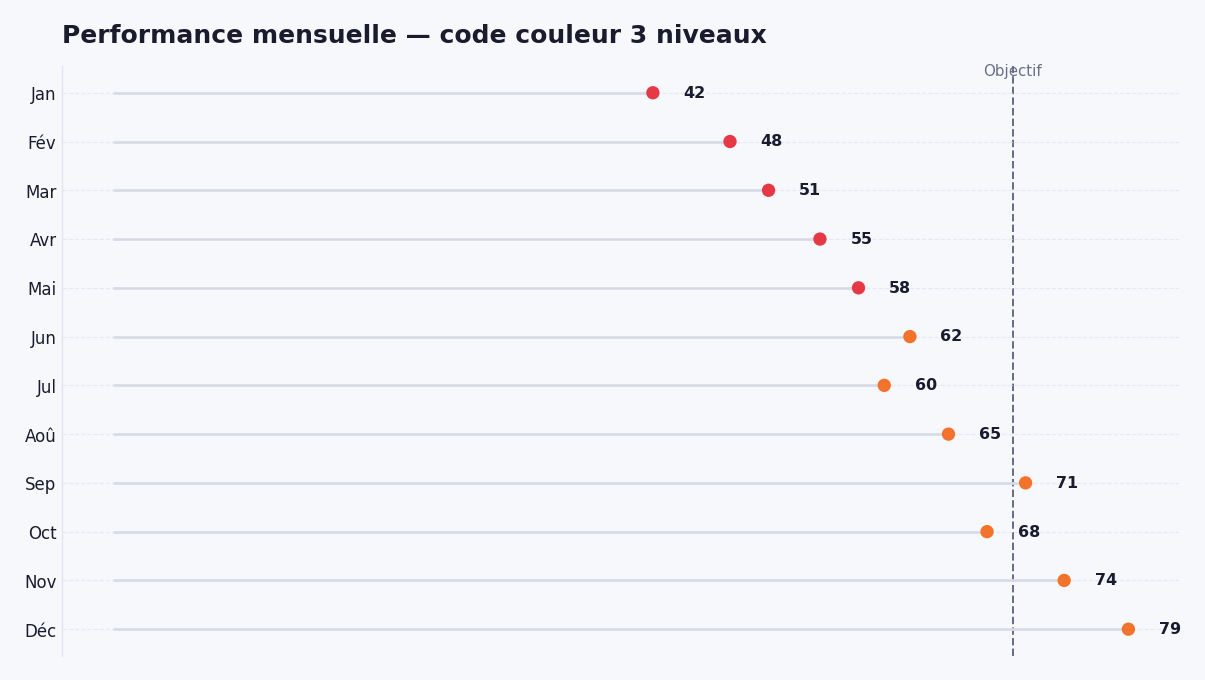

In [41]:
# colorier_selon — 3 niveaux (feu tricolore)
fn_perf = colorier_selon([
    (lambda v: v >= 80, "#2DC653"),   # vert  — excellent
    (lambda v: v >= 60, "#F3722C"),   # orange — correct
    (True,              "#E63946"),   # rouge  — insuffisant
])

lollipop(
    categories=mois,
    valeurs=ventes_douala,
    fn_couleur=fn_perf,
    titre="Performance mensuelle — code couleur 3 niveaux",
    ligne_ref=70, label_ref="Objectif",
    trier=False,
)
plt.show()

### 6.4 `init(theme=)` — thème clair, sombre ou personnalisé

Le thème s'applique à **tous** les graphiques de la session. Aucun paramètre à passer à chaque fonction.

✓ Style beau_graphique activé (thème : dark).


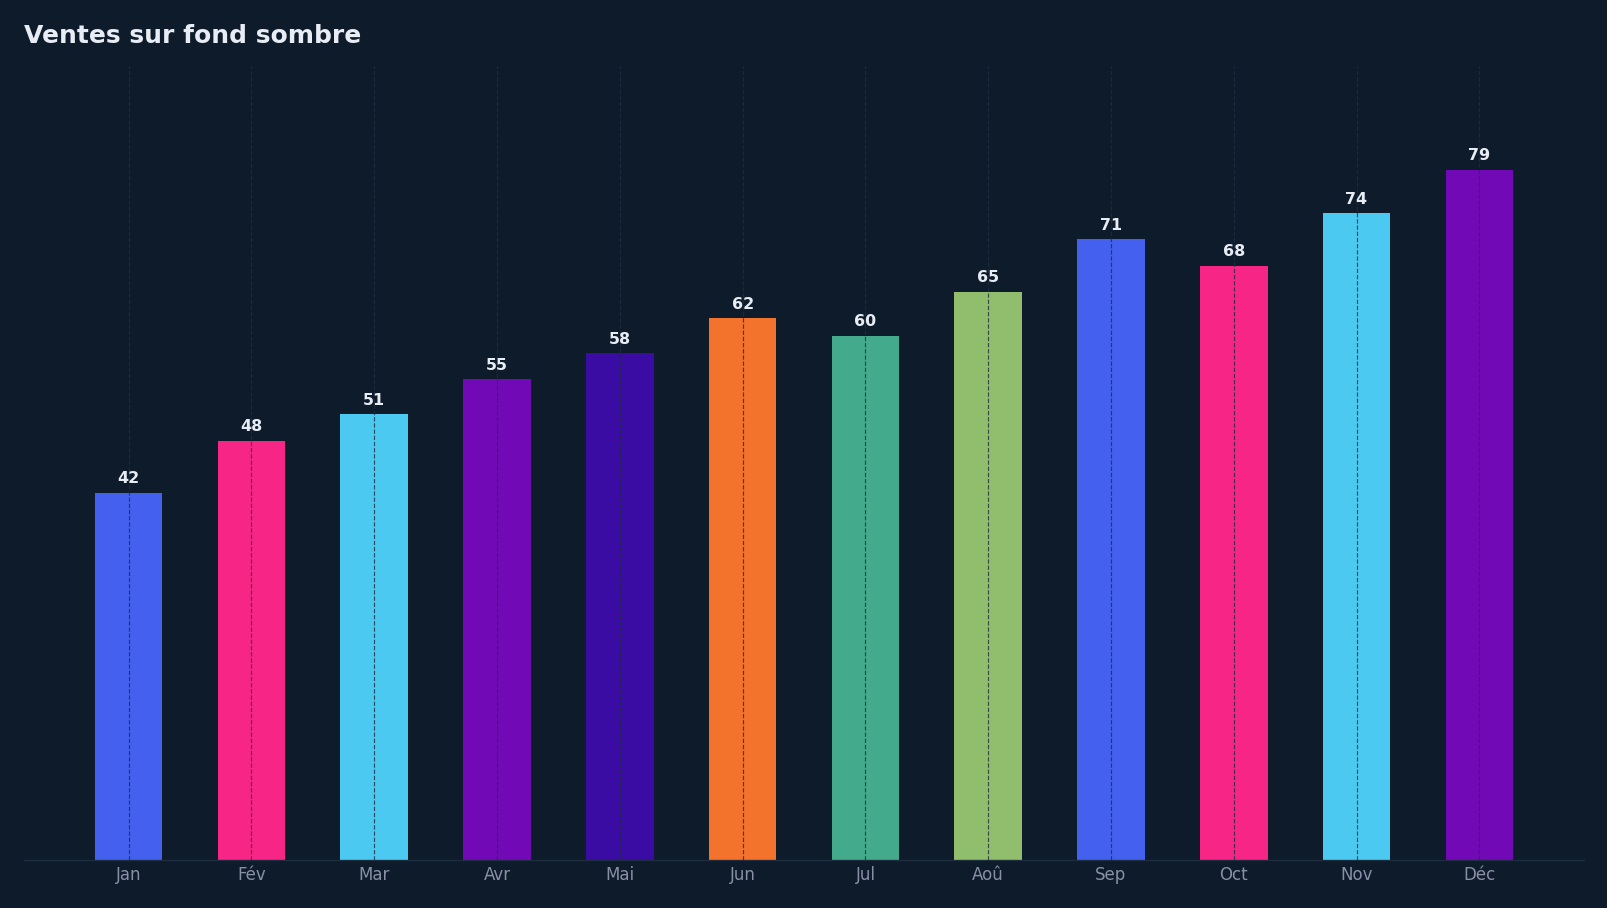

In [42]:
# Thème sombre — idéal pour slides dark, présentations nocturnes
init(theme="dark")

barres(
    mois, ventes_douala,
    titre="Ventes sur fond sombre",
    couleurs_multiples=True,
    format="slide",
)
plt.show()

✓ Style beau_graphique activé (thème : personnalisé).


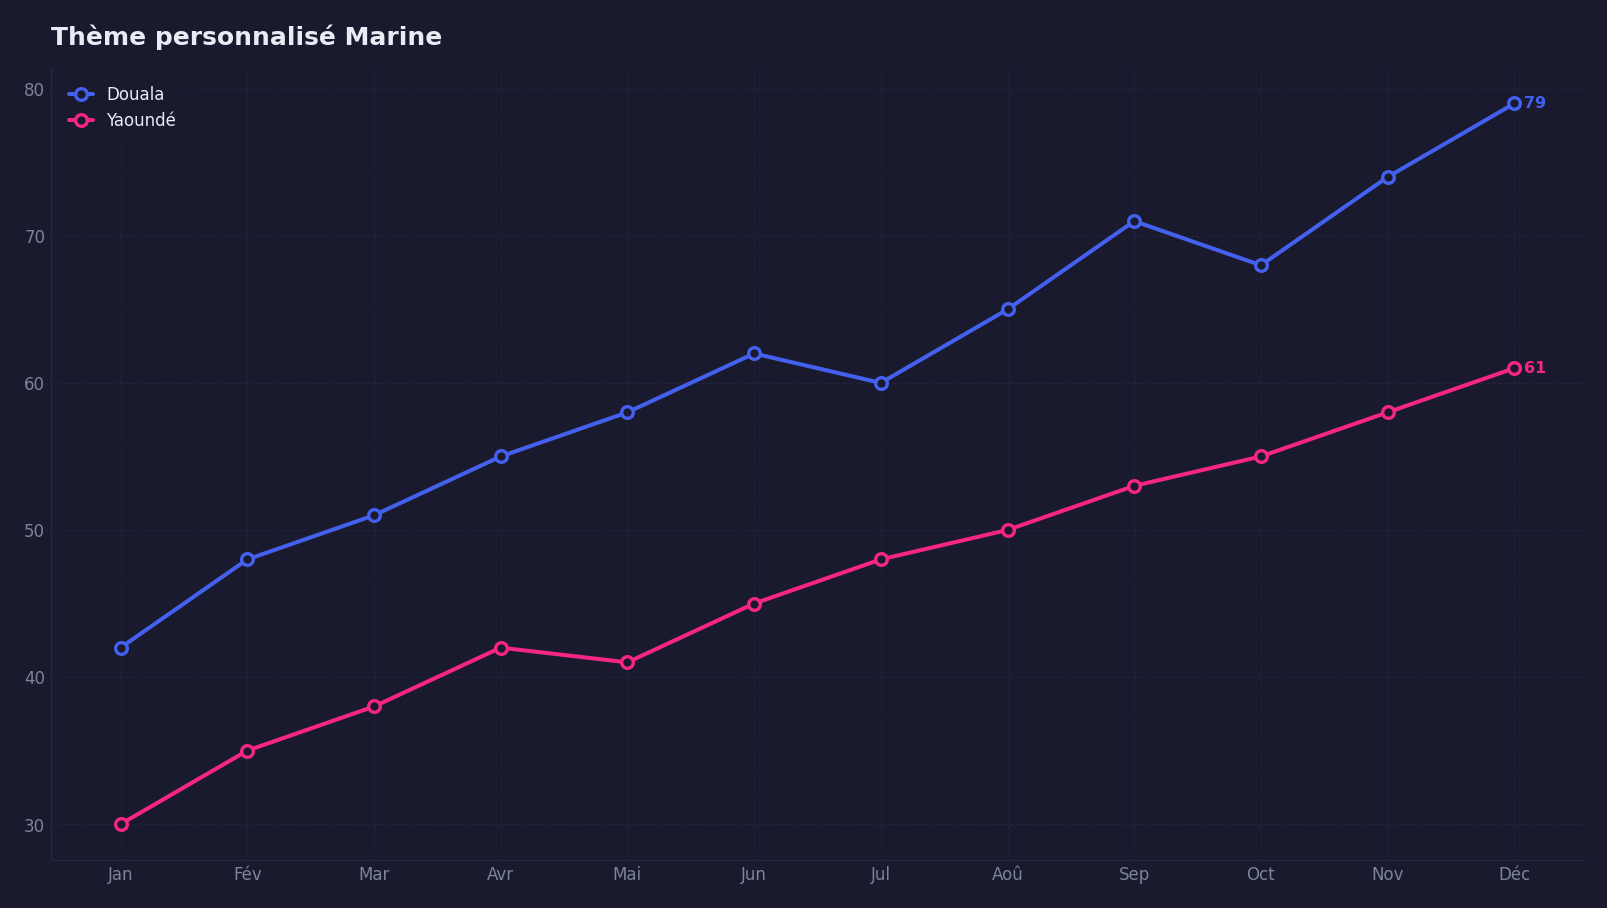

✓ Style beau_graphique activé (thème : light).


In [43]:
# Thème personnalisé — adapte la librairie à ta charte graphique
init(theme={
    "bg":          "#1A1A2E",   # fond marine profond
    "texte":       "#E8ECF4",
    "texte_dim":   "#7B8499",
    "grille":      "#252545",
    "fond_neutre": "#1A1A2E",
    "serie_dim":   "#3C4A66",
})

ligne(
    x=mois,
    y_series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    titre="Thème personnalisé Marine",
    format="slide",
)
plt.show()

init()  # ← remettre en thème clair pour la suite

### 6.5 `export.py` — sauvegarder, PDF multi-pages, batch

| Fonction | Usage |
|---|---|
| `sauvegarder(fig, nom, fmt=...)` | Un fichier PNG / SVG / PDF |
| `pdf_rapport(figures, nom)` | Plusieurs figures → un PDF multi-pages |
| `export_batch({nom: fig}, fmt=...)` | Plusieurs fichiers en une ligne |

In [44]:
import os

# Sauvegarder un seul graphique
fig, ax = barres(mois, ventes_douala, titre="Ventes Douala")
os.makedirs("exports_demo", exist_ok=True)
chemin = sauvegarder(fig, "ventes_douala", dossier="exports_demo/", fmt="png")
print(f"Fichier créé : {chemin}")
plt.close("all")

  ✓ exports_demo\ventes_douala.png
Fichier créé : exports_demo\ventes_douala.png


In [45]:
# PDF multi-pages — chaque figure devient une page
fig1, _ = barres(mois, ventes_douala, titre="Ventes Douala")
fig2, _ = ligne(mois, {"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
               titre="Comparatif villes")
fig3, _ = camembert(
    labels=["Littoral", "Centre", "Ouest", "Autres"],
    valeurs=[42, 28, 18, 12],
    titre="Parts de marché",
)

pdf_rapport(
    [(fig1, "Analyse Douala"), (fig2, "Comparatif"), fig3],
    nom="rapport_demo",
    dossier="exports_demo/",
    titre="Rapport commercial — Démo",
    auteur="beau_graphique",
)
plt.close("all")

  ✓ exports_demo\rapport_demo.pdf  (3 pages)


In [46]:
# Export en masse — dict {nom: fig}
figs = {}
for ville, ventes in [("douala", ventes_douala), ("yaounde", ventes_yaounde)]:
    fig, _ = barres(mois, ventes, titre=f"Ventes {ville.capitalize()}")
    figs[f"ventes_{ville}"] = fig

export_batch(figs, dossier="exports_demo/", fmt=["png", "svg"])
plt.close("all")

Export batch → exports_demo/  (2 figure(s), fmt=png+svg)
  ✓ exports_demo\ventes_douala.png
  ✓ exports_demo\ventes_douala.svg


  ✓ exports_demo\ventes_yaounde.png
  ✓ exports_demo\ventes_yaounde.svg
  4 fichier(s) créé(s).


### 6.6 `layout_rapport()` — gabarit slide/rapport complet

Crée en un appel :
- Un en-tête avec titre et sous-titre
- Des tuiles KPI (valeur + delta coloré)
- Des axes graphiques prêts à recevoir `barres()`, `ligne()`, etc. via `ax=`

```
┌───────────────────────────┬──────────┬──────────┬──────────┐
│ Titre                     │  KPI 1   │  KPI 2   │  KPI 3   │
│ Sous-titre                │  1,24 M  │  4 832   │  23 %    │
│                           │ ▲ +12 %  │ ▲ +5 %   │ ▼ −2 pts │
├───────────────────────────┴──────────┴──────────┴──────────┤
│                Graphique 1           │      Graphique 2     │
└──────────────────────────────────────┴─────────────────────┘
```

✓ Style beau_graphique activé (thème : light).


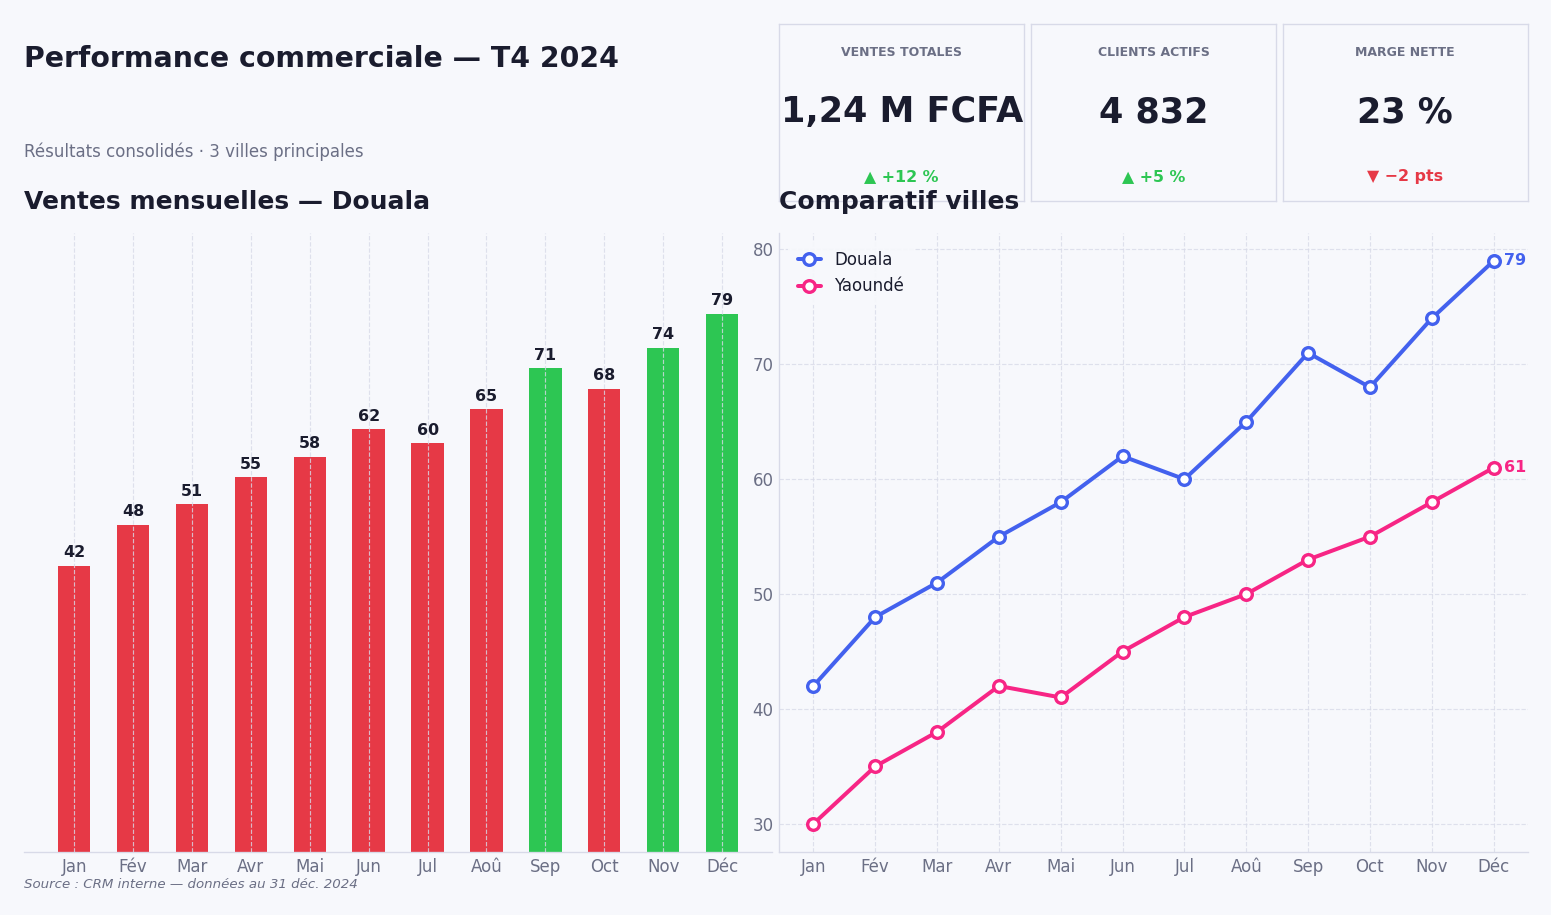

In [47]:
init()

fig, zones = layout_rapport(
    titre="Performance commerciale — T4 2024",
    sous_titre="Résultats consolidés · 3 villes principales",
    note="Source : CRM interne — données au 31 déc. 2024",
    kpis=[
        {"label": "Ventes totales", "valeur": "1,24 M FCFA", "delta": "+12 %",   "positif": True},
        {"label": "Clients actifs", "valeur": "4 832",       "delta": "+5 %",    "positif": True},
        {"label": "Marge nette",    "valeur": "23 %",        "delta": "−2 pts",  "positif": False},
    ],
    n_graphiques=2,
    format="slide",
)

# Remplir les zones avec les fonctions habituelles
barres(
    mois, ventes_douala,
    titre="Ventes mensuelles — Douala",
    fn_couleur=colorier_si(70),
    ax=zones["graphiques"][0],
)

ligne(
    x=mois,
    y_series={"Douala": ventes_douala, "Yaoundé": ventes_yaounde},
    titre="Comparatif villes",
    ax=zones["graphiques"][1],
)

plt.show()

✓ Style beau_graphique activé (thème : dark).


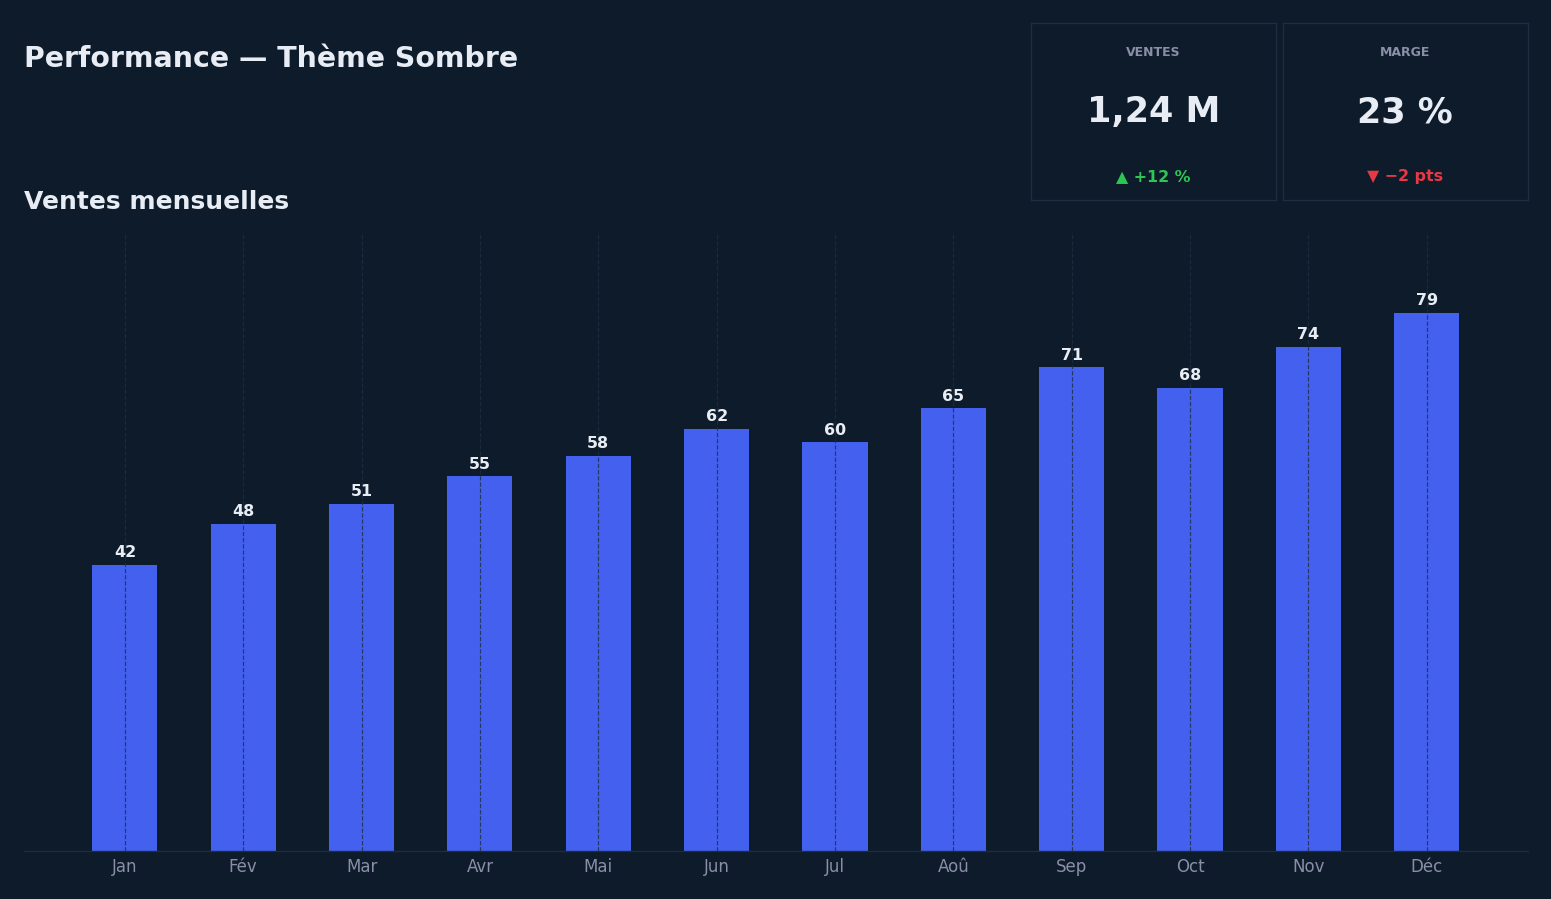

✓ Style beau_graphique activé (thème : light).


In [48]:
# Même layout en thème sombre
init(theme="dark")

fig_dark, zones_dark = layout_rapport(
    titre="Performance — Thème Sombre",
    kpis=[
        {"label": "Ventes", "valeur": "1,24 M", "delta": "+12 %", "positif": True},
        {"label": "Marge",  "valeur": "23 %",   "delta": "−2 pts","positif": False},
    ],
    n_graphiques=1,
    format="slide",
)

barres(mois, ventes_douala, titre="Ventes mensuelles", ax=zones_dark["graphiques"][0])
plt.show()

init()  # reset

## 7. Workflow complet — de la donnée à la slide exportée

Ce scénario simule un vrai cas d'usage : tu reçois des données, tu produis un rapport visuel et tu l'exportes en PDF + PNG, le tout en moins de 30 lignes.

**Contexte :** bilan commercial trimestriel pour 3 villes.

✓ Style beau_graphique activé (thème : light).


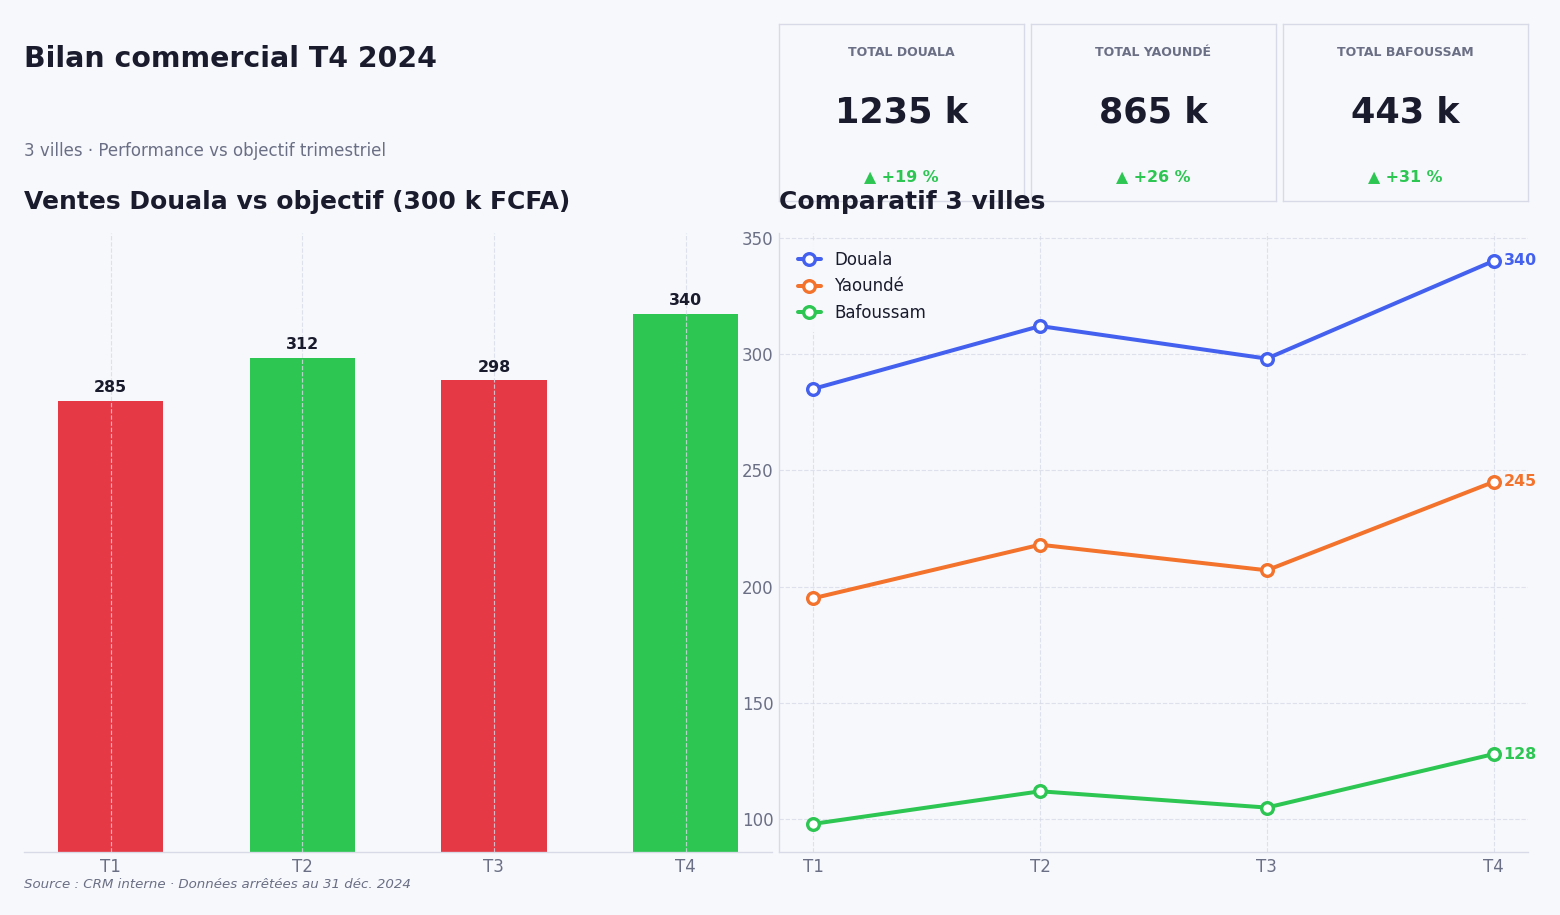

  ✓ exports_workflow\slide_bilan_t4.png
  ✓ exports_workflow\rapport_bilan_t4.pdf  (4 pages)

✓ Rapport généré dans exports_workflow/


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from beau_graphique import (
    init, barres, ligne, layout_rapport,
    enregistrer_couleurs, colorier_si,
)
from export import sauvegarder, pdf_rapport
import os

# ── 1. Données ────────────────────────────────────────────────────────────────
np.random.seed(42)
trimestres = ["T1", "T2", "T3", "T4"]
ventes = {
    "Douala":    [285, 312, 298, 340],
    "Yaoundé":   [195, 218, 207, 245],
    "Bafoussam": [98,  112, 105, 128],
}
objectif = 300  # k FCFA

# ── 2. Cohérence des couleurs ─────────────────────────────────────────────────
init()
enregistrer_couleurs({
    "Douala":    "#4361EE",
    "Yaoundé":   "#F3722C",
    "Bafoussam": "#2DC653",
})

# ── 3. Slide principale ───────────────────────────────────────────────────────
fig_slide, zones = layout_rapport(
    titre="Bilan commercial T4 2024",
    sous_titre="3 villes · Performance vs objectif trimestriel",
    note="Source : CRM interne · Données arrêtées au 31 déc. 2024",
    kpis=[
        {"label": "Total Douala",    "valeur": f"{sum(ventes['Douala'])} k",
         "delta": "+19 %", "positif": True},
        {"label": "Total Yaoundé",   "valeur": f"{sum(ventes['Yaoundé'])} k",
         "delta": "+26 %", "positif": True},
        {"label": "Total Bafoussam", "valeur": f"{sum(ventes['Bafoussam'])} k",
         "delta": "+31 %", "positif": True},
    ],
    n_graphiques=2,
    format="slide",
)

barres(
    trimestres, ventes["Douala"],
    titre="Ventes Douala vs objectif (300 k FCFA)",
    fn_couleur=colorier_si(objectif),
    ax=zones["graphiques"][0],
)

ligne(
    x=trimestres,
    y_series=ventes,
    titre="Comparatif 3 villes",
    ax=zones["graphiques"][1],
)

plt.show()

# ── 4. Graphiques détail (pour le PDF) ────────────────────────────────────────
figs_detail = []
for ville, vals in ventes.items():
    fig_d, _ = barres(
        trimestres, vals,
        titre=f"Ventes {ville} — détail trimestriel",
        fn_couleur=colorier_si(objectif),
    )
    figs_detail.append((fig_d, ville))
plt.close("all")

# ── 5. Export ─────────────────────────────────────────────────────────────────
os.makedirs("exports_workflow", exist_ok=True)

sauvegarder(fig_slide, "slide_bilan_t4",
            dossier="exports_workflow/", fmt=["png"])

pdf_rapport(
    [(fig_slide, "Vue d'ensemble")] + figs_detail,
    nom="rapport_bilan_t4",
    dossier="exports_workflow/",
    titre="Bilan commercial T4 2024",
    auteur="beau_graphique",
)

reinitialiser_couleurs()
print("\n✓ Rapport généré dans exports_workflow/")